# Stage 0 -- E-E Backbone Notebook, v10

This notebook organizes the analysis into three interpretable parts:

- **Stage 0 — E-only greedy backbone:** follows the strongest positive E→E transitions to identify the dominant excitatory scaffold.
- **Stage 1 — Alternating E/I/E greedy tree:** adds inhibitory nodes directly into the greedy traver
- sal by alternating `E → I → E` until the path terminates.

## Section 0 — Setup and configuration

Run this section first. It tries to use your existing `cross_platform_setup` if available, but falls back to local paths if not.

In [1]:
# ============================================================================
# Section 0 — Setup and configuration
# ============================================================================

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CROSS_PLATFORM_SETUP = True

if USE_CROSS_PLATFORM_SETUP:
    try:
        from cross_platform_setup import setup_jupyter_notebook
        config = setup_jupyter_notebook(
            onedrive_path='04_2026 Spring/Ascoli Lab Rotation/Final Project',
            required_files=[
                ('w_ij_gaa.csv', 'Weight matrix'),
                ('izhikevich_72_v3.csv', 'Izhikevich parameters'),
            ],
        )
        BASE_PATH    = Path(config.base_path)
        MATRICES_DIR = Path(config.get_dir('matrices'))
        OUTPUT_DIR   = Path(config.get_dir('outputs')) / 'stage01_corrected'
    except Exception as e:
        print('cross_platform_setup not available. Falling back to local paths.')
        print(f'Reason: {e}')
        BASE_PATH    = Path.cwd()
        MATRICES_DIR = BASE_PATH / 'matrices'
        OUTPUT_DIR   = BASE_PATH / 'outputs' / 'stage01_corrected'
else:
    BASE_PATH    = Path.cwd()
    MATRICES_DIR = BASE_PATH / 'matrices'
    OUTPUT_DIR   = BASE_PATH / 'outputs' / 'stage01_corrected'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.set_printoptions(precision=4, suppress=True)

print('Setup complete')
print(f'BASE_PATH:    {BASE_PATH}')
print(f'MATRICES_DIR: {MATRICES_DIR}')
print(f'OUTPUT_DIR:   {OUTPUT_DIR}')


✓ Found project at: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/Ascoli Lab Rotation/Final Project

ENVIRONMENT CONFIGURATION
Platform:        macos
System:          Darwin
Architecture:    arm64
Python version:  3.13.12
Base path:       /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/Ascoli Lab Rotation/Final Project

DIRECTORIES
✓ matrices             /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/Ascoli Lab Rotation/Final Project/matrices
✓ outputs              /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/Ascoli Lab Rotation/Final Project/outputs

DATA FILES CHECK
✗ w_ij_gaa.csv                   Weight matrix                  NOT FOUND
✗ izhikevich_72_v3.csv           Izhikevich parameters          NOT FOUND

M1/M2 NATIVE ARCHITECTURE DETECTED

Note: You're running on Apple Sili

## Section 1 — Load matrix and E/I metadata

This section is deliberately defensive. It checks for square matrices, row/column alignment, missing E/I labels, and duplicate labels.

**Note**: the naming mask was used to reconcile discrepancy of neuron cell type names between files; at this point in developing the workflow, this is arbitrary, as both types are excitatory, but should not be seen as equal and noted when performing analysis.

In [2]:
# ============================================================================
# Section 1 — Load matrix and E/I metadata
# ============================================================================

# ---------------------------------------------------------------------------
# Matrix selection — switch to M_ij here when Jean's full K_j vector is ready.
# Do NOT enable USE_M_IJ until the complete K_j vector covering all nodes is
# available; a partial K_j silently biases weights for unpatched nodes.
# ---------------------------------------------------------------------------
USE_M_IJ = True   # True → use M_ij (W_ij × K_j); False → use W_ij (default)

if USE_M_IJ:
    WEIGHT_FILE = MATRICES_DIR / "m_ij_85.csv"   
    IZH_FILE = MATRICES_DIR / "ei_metadata_85.csv"
else:
    WEIGHT_FILE = MATRICES_DIR / "w_ij_85.csv"
    IZH_FILE = MATRICES_DIR / "izhikevich_72_v4.csv"

# If your files are somewhere else, override these manually, for example:
# WEIGHT_FILE = Path("/path/to/w_ij_gaa.csv")
# IZH_FILE    = Path("/path/to/izhikevich_72_v3.csv")

assert WEIGHT_FILE.exists(), f"Weight matrix not found: {WEIGHT_FILE}"
assert IZH_FILE.exists(),    f"Izhikevich metadata not found: {IZH_FILE}"

W_raw = pd.read_csv(WEIGHT_FILE, index_col=0)
izh_raw = pd.read_csv(IZH_FILE)

# Naming patch: applied via rename() so it works regardless of matrix size.
# Add additional entries here as new mismatches are discovered.
NAME_PATCH = {
    "MEC LV Multipolar Pyramidal": "MEC LIII Multipolar Principal",
}

W = W_raw.copy()
W.rename(index=NAME_PATCH, columns=NAME_PATCH, inplace=True)

# Coerce matrix values to numeric.
W = W.apply(pd.to_numeric, errors="coerce").fillna(0).copy()

print(f"Loaded: {WEIGHT_FILE.name}  ({'M_ij' if USE_M_IJ else 'W_ij'})")
print(f"Weight matrix shape: {W.shape}")
print(f"Izhikevich metadata shape: {izh_raw.shape}")

Loaded: m_ij_85.csv  (M_ij)
Weight matrix shape: (85, 85)
Izhikevich metadata shape: (85, 2)


In [3]:
# ============================================================================
# Section 1b — Build E/I node lists robustly
# ============================================================================

# Identify neuron-name column in metadata.
possible_name_cols = ["Neuron Type", "Neuron", "node", "Node", "name", "Name"]
name_col = next((c for c in possible_name_cols if c in izh_raw.columns), izh_raw.columns[0])

# Identify E/I column.
possible_ei_cols = ["E/I", "EI", "e/i", "Type", "type", "Class", "class"]
ei_col = next((c for c in possible_ei_cols if c in izh_raw.columns), None)
assert ei_col is not None, f"Could not find E/I column. Available columns: {list(izh_raw.columns)}"

izh = izh_raw.copy()
izh[name_col] = izh[name_col].astype(str).replace(NAME_PATCH)

# Normalize E/I labels to 'e' / 'i' via dict lookup; unknown values become NaN.
_EI_NORM = {
    "e": "e", "exc": "e", "excitatory": "e",
    "i": "i", "inh": "i", "inhibitory": "i",
}
izh["ei_clean"] = izh[ei_col].astype(str).str.lower().str.strip().map(_EI_NORM)
ei_map = dict(zip(izh[name_col], izh["ei_clean"]))

exc_nodes = [n for n in W.index if ei_map.get(n) == "e"]
inh_nodes = [n for n in W.index if ei_map.get(n) == "i"]
unclassified_nodes = [n for n in W.index if n not in set(exc_nodes + inh_nodes)]

print("E/I classification")
print(f"Excitatory nodes: {len(exc_nodes)}")
print(f"Inhibitory nodes: {len(inh_nodes)}")
print(f"Unclassified nodes: {len(unclassified_nodes)}")

if unclassified_nodes:
    print("\nUnclassified nodes in W not found in E/I metadata:")
    for n in unclassified_nodes[:20]:
        print("  -", n)
    if len(unclassified_nodes) > 20:
        print(f"  ... plus {len(unclassified_nodes)-20} more")

E/I classification
Excitatory nodes: 32
Inhibitory nodes: 53
Unclassified nodes: 0


## Section 2 — Validate matrix structure

This catches the most common causes of silent errors before any path analysis runs.

In [4]:
# ============================================================================
# Section 2 — Matrix validation
# ============================================================================

assert W.shape[0] == W.shape[1], "W must be square."
assert W.index.is_unique, "W.index contains duplicate node labels."
assert W.columns.is_unique, "W.columns contains duplicate node labels."

if list(W.index) != list(W.columns):
    print("WARNING: W.index and W.columns contain the same labels but not in the same order, or differ.")
    missing_from_cols = sorted(set(W.index) - set(W.columns))
    missing_from_rows = sorted(set(W.columns) - set(W.index))
    print(f"Labels in rows but not columns: {len(missing_from_cols)}")
    print(f"Labels in columns but not rows: {len(missing_from_rows)}")
    assert len(missing_from_cols) == 0 and len(missing_from_rows) == 0, "Row/column labels do not match."
    W = W.loc[W.index, W.index].copy()
    print("Reordered columns to match rows.")

missing_E_rows = [n for n in exc_nodes if n not in W.index]
missing_E_cols = [n for n in exc_nodes if n not in W.columns]
missing_I_rows = [n for n in inh_nodes if n not in W.index]
missing_I_cols = [n for n in inh_nodes if n not in W.columns]

assert not missing_E_rows, f"Excitatory nodes missing from W.index: {missing_E_rows}"
assert not missing_E_cols, f"Excitatory nodes missing from W.columns: {missing_E_cols}"
assert not missing_I_rows, f"Inhibitory nodes missing from W.index: {missing_I_rows}"
assert not missing_I_cols, f"Inhibitory nodes missing from W.columns: {missing_I_cols}"

n_nonzero = int((W != 0).sum().sum())
n_pos     = int((W > 0).sum().sum())
n_neg     = int((W < 0).sum().sum())

print("Matrix validation passed")
print(f"Nodes: {W.shape[0]}")
print(f"Nonzero weights: {n_nonzero}")
print(f"Positive weights: {n_pos}")
print(f"Negative weights: {n_neg}")
print(f"E/I accounted nodes: {len(exc_nodes) + len(inh_nodes)} / {W.shape[0]}")

if len(exc_nodes) != 27:
    print(f"\nNOTE: This dataset has {len(exc_nodes)} excitatory nodes.")

Matrix validation passed
Nodes: 85
Nonzero weights: 1641
Positive weights: 734
Negative weights: 907
E/I accounted nodes: 85 / 85

NOTE: This dataset has 32 excitatory nodes.


## Section 3 — Build signed block matrices

The block matrices keep sign information where appropriate, but Stage 0 uses only positive E→E edges.

In [5]:
# ============================================================================
# Section 3 — Build signed block matrices
# ============================================================================

# Raw signed blocks.
W_EE_signed = W.loc[exc_nodes, exc_nodes].copy()
W_EI_signed = W.loc[exc_nodes, inh_nodes].copy()
W_IE_signed = W.loc[inh_nodes, exc_nodes].copy()
W_II_signed = W.loc[inh_nodes, inh_nodes].copy()

# Remove self-loops: work on a plain numpy array to avoid the read-only
# DataFrame .values issue, then wrap back into a DataFrame.
def _zero_diagonal(df):
    arr = df.to_numpy().copy()
    np.fill_diagonal(arr, 0)
    return pd.DataFrame(arr, index=df.index, columns=df.columns)

W_EE_signed = _zero_diagonal(W_EE_signed)
W_II_signed = _zero_diagonal(W_II_signed)

# Stage 0: only positive E→E weights.
W_EE_pos = W_EE_signed.clip(lower=0).copy()

# Stage 1 components:
# E→I activation: keep only positive E→I for activation.
W_EI_pos = W_EI_signed.clip(lower=0).copy()

# I→E suppression: use magnitude for inhibition strength.
W_IE_inhib_mag = (-W_IE_signed.clip(upper=0)).copy()

# Keep signed I→I for optional effective connectivity.
W_II_signed = W_II_signed.copy()

n_E = len(exc_nodes)
n_I = len(inh_nodes)
n_EE_possible = n_E * (n_E - 1)
n_EE_pos  = int((W_EE_pos > 0).sum().sum())
n_EI_pos  = int((W_EI_pos > 0).sum().sum())
n_IE_inhib = int((W_IE_inhib_mag > 0).sum().sum())

print("Block matrix summary")
print(f"W_EE_pos:       {W_EE_pos.shape}, positive edges = {n_EE_pos}")
print(f"W_EI_pos:       {W_EI_pos.shape}, positive E→I edges = {n_EI_pos}")
print(f"W_IE_inhib_mag: {W_IE_inhib_mag.shape}, inhibitory I→E edges = {n_IE_inhib}")
print(f"W_II_signed:    {W_II_signed.shape}")
if n_EE_possible > 0:
    print(f"E→E positive density: {100 * n_EE_pos / n_EE_possible:.2f}%")

Block matrix summary
W_EE_pos:       (32, 32), positive edges = 355
W_EI_pos:       (32, 53), positive E→I edges = 352
W_IE_inhib_mag: (53, 32), inhibitory I→E edges = 171
W_II_signed:    (53, 53)
E→E positive density: 35.79%


## Section 4 — Stage 0: E-only greedy backbone

Stage 0 asks: if only the positive E→E scaffold is followed greedily, where does each excitatory start node terminate?

In [6]:
# ============================================================================
# Section 4 — Stage 0 greedy pathway function
# ============================================================================

def greedy_positive_path(start_node, weight_matrix, max_steps=None):
    """
    Greedy path over positive outgoing weights.

    Parameters
    ----------
    start_node : str
        Start node label.
    weight_matrix : pd.DataFrame
        Square weighted adjacency matrix with source nodes as rows and targets as columns.
        Only weights > 0 are considered valid routing edges.
    max_steps : int or None
        If None, uses number of nodes - 1.

    Returns
    -------
    dict
        Path, edge records, skipped revisits, terminus, and weight summary.
    """
    assert start_node in weight_matrix.index,   f"{start_node} not in matrix index."
    assert start_node in weight_matrix.columns, f"{start_node} not in matrix columns."

    nodes = list(weight_matrix.index)
    if max_steps is None:
        max_steps = len(nodes) - 1

    path = [start_node]
    visited = {start_node}
    skipped_revisits = []
    edge_records = []
    cumulative_weight = 0.0
    current = start_node

    for step in range(max_steps):
        outgoing = weight_matrix.loc[current].copy()
        outgoing = outgoing[outgoing > 0].sort_values(ascending=False)

        next_node = None
        next_weight = None

        for candidate, weight in outgoing.items():
            if candidate in visited:
                skipped_revisits.append({
                    "step": step,
                    "from_node": current,
                    "skipped_target": candidate,
                    "skipped_weight": float(weight),
                    "reason": "already_visited",
                })
                continue
            next_node = candidate
            next_weight = float(weight)
            break

        if next_node is None:
            terminated_because = "no_unvisited_positive_targets"
            break

        edge_records.append({
            "step": step,
            "from_node": current,
            "to_node": next_node,
            "weight": next_weight,
        })
        path.append(next_node)
        visited.add(next_node)
        cumulative_weight += next_weight
        current = next_node
    else:
        terminated_because = "max_steps_reached"

    n_edges = len(path) - 1
    return {
        "start_node": start_node,
        "terminus": path[-1],
        "path": path,
        "path_length_nodes": len(path),
        "n_edges": n_edges,
        "cumulative_weight": cumulative_weight,
        "mean_edge_weight": cumulative_weight / n_edges if n_edges else 0.0,
        "skipped_revisits": skipped_revisits,
        "edge_records": edge_records,
        "terminated_because": terminated_because,
    }

In [7]:
# ============================================================================
# Section 4b — Run Stage 0 from all excitatory nodes
# ============================================================================

stage0_results = [greedy_positive_path(n, W_EE_pos) for n in exc_nodes]

_EXCLUDE = {"skipped_revisits", "edge_records", "path"}
stage0_paths_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in _EXCLUDE}
    | {"n_skipped_revisits": len(r["skipped_revisits"]),
       "path_string": " → ".join(r["path"])}
    for r in stage0_results
])

stage0_edges_df = pd.DataFrame([
    {"start_node": r["start_node"], **edge}
    for r in stage0_results
    for edge in r["edge_records"]
])

stage0_skips_df = pd.DataFrame([
    {"start_node": r["start_node"], **skip}
    for r in stage0_results
    for skip in r["skipped_revisits"]
])

print("Stage 0 complete")
print(f"Paths computed: {len(stage0_paths_df)}")
print(f"Unique termini: {stage0_paths_df['terminus'].nunique()}")
print(f"Total path-weighted E→E transitions: {len(stage0_edges_df)}")

display(stage0_paths_df.sort_values(["terminus", "path_length_nodes"], ascending=[True, False]))

display(
    stage0_paths_df["terminus"]
    .value_counts()
    .rename_axis("terminus")
    .reset_index(name="n_paths")
)

Stage 0 complete
Paths computed: 32
Unique termini: 4
Total path-weighted E→E transitions: 534


,start_node,terminus,path_length_nodes,n_edges,cumulative_weight,mean_edge_weight,terminated_because,n_skipped_revisits,path_string
15,EC LIII Stellate,CA1 Radiatum Giant,23,22,194837.714827,8856.259765,no_unvisited_positive_targets,23,EC LIII Stellate → MEC LIII Complex Pyramidal ...
23,MEC LII Oblique Pyramidal,CA1 Radiatum Giant,23,22,195127.342493,8869.424659,no_unvisited_positive_targets,23,MEC LII Oblique Pyramidal → MEC LIII Complex P...
24,MEC LII Stellate,CA1 Radiatum Giant,23,22,194238.904351,8829.041107,no_unvisited_positive_targets,23,MEC LII Stellate → CA3 Granule → CA3c Pyramida...
26,MEC LIII Complex Pyramidal,CA1 Radiatum Giant,22,21,194671.902598,9270.090600,no_unvisited_positive_targets,23,MEC LIII Complex Pyramidal → MEC LII Stellate ...
27,MEC LIII Multipolar Principal,CA1 Radiatum Giant,22,21,194829.737962,9277.606570,no_unvisited_positive_targets,21,MEC LIII Multipolar Principal → MEC LIII Compl...
29,MEC LV Superficial Pyramidal,CA1 Radiatum Giant,22,21,195006.648002,9286.030857,no_unvisited_positive_targets,21,MEC LV Superficial Pyramidal → MEC LIII Comple...
22,MEC LII III Pyramidal Multiform,CA1 Radiatum Giant,19,18,71071.143717,3948.396873,no_unvisited_positive_targets,18,MEC LII III Pyramidal Multiform → MEC LV VI Py...
17,EC LIV VI Deep Multipolar Principal,CA1 Radiatum Giant,18,17,69254.617516,4073.801030,no_unvisited_positive_targets,16,EC LIV VI Deep Multipolar Principal → MEC LV V...
18,EC LV Deep Pyramidal,CA1 Radiatum Giant,18,17,68952.172177,4056.010128,no_unvisited_positive_targets,15,EC LV Deep Pyramidal → MEC LV VI Pyramidal Pol...
20,LEC LIII Multipolar Principal,CA1 Radiatum Giant,18,17,76211.233646,4483.013744,no_unvisited_positive_targets,20,LEC LIII Multipolar Principal → LEC LIII Compl...


,terminus,n_paths
0,CA1 Radiatum Giant,28
1,DG Hilar Ectopic Granule,2
2,CA3 Pyramidal,1
3,CA3 Granule,1


## Section 4c — Stage 0 / Stage 1a: Greedy path lookup

Utilities for inspecting the ordered node sequence of any excitatory start node.

- `print_stage0_path(name)` — E-only greedy path with edge weights.
- `print_stage1a_path(name)` — full alternating E→I→E path with signed weights.
- `print_all_stage0_paths()` — all excitatory start node paths in sequence.

Both functions suggest close matches on a typo.

In [8]:
# ============================================================================
# Section 4c — Greedy path lookup utilities (Stage 0 and Stage 1a)
# ============================================================================

def _find_match(start_node, results, key):
    match = next((r for r in results if r[key] == start_node), None)
    if match is None:
        available = [r[key] for r in results]
        close = [n for n in available if start_node.lower() in n.lower()]
        print(f"Node '{start_node}' not found.")
        if close:
            print('Did you mean one of these?')
            for n in close:
                print(f'  {n}')
        else:
            print('Available nodes:')
            for n in available:
                print(f'  {n}')
    return match


def print_stage0_path(start_node, results=None):
    """Print the Stage 0 E-only greedy path with edge weights."""
    if results is None:
        results = stage0_results
    match = _find_match(start_node, results, 'start_node')
    if match is None:
        return
    path     = match['path']
    print(f"Start:    {start_node}")
    print(f"Steps:    {match['n_edges']}  |  Terminus: {match['terminus']}")
    print()
    for i, node in enumerate(path):
        prefix = f'  {i:>2}: '
        if i < len(path) - 1:
            w = match['edge_records'][i]['weight']
            print(f"{prefix}{node}  [w={w:.3e}] ->")
        else:
            print(f"{prefix}{node}   [TERMINUS]")
    print(f"\n  Cumulative weight: {match['cumulative_weight']:.3e}")
    print(f"  Stop: {match['terminated_because']}")

### All Stage 0 Greedy Trees

In [9]:
def print_all_stage0_paths(results=None):
    """Print Stage 0 greedy paths for all excitatory start nodes."""
    if results is None:
        results = stage0_results
    for r in results:
        print_stage0_path(r['start_node'], results=results)
        print()

print_all_stage0_paths()

Start:    CA1 Pyramidal
Steps:    15  |  Terminus: CA1 Radiatum Giant

   0: CA1 Pyramidal  [w=1.356e+04] ->
   1: MEC LV VI Pyramidal Polymorphic  [w=8.678e+01] ->
   2: EC LIV VI Deep Multipolar Principal  [w=2.246e+03] ->
   3: LEC LVI Multipolar Pyramidal  [w=3.040e+02] ->
   4: LEC LIII Multipolar Principal  [w=5.561e+02] ->
   5: LEC LIII Complex Pyramidal  [w=5.381e+02] ->
   6: EC LIII Pyramidal Stellate  [w=6.474e+02] ->
   7: MEC LIII Complex Pyramidal  [w=1.193e+03] ->
   8: MEC LII Stellate  [w=1.964e+04] ->
   9: CA3 Granule  [w=2.281e+00] ->
  10: CA3c Pyramidal  [w=2.442e+04] ->
  11: CA2 Pyramidal  [w=4.836e+03] ->
  12: DG Mossy  [w=2.120e+03] ->
  13: DG Hilar Ectopic Granule  [w=1.330e-02] ->
  14: CA3 Pyramidal  [w=3.037e+02] ->
  15: CA1 Radiatum Giant   [TERMINUS]

  Cumulative weight: 7.046e+04
  Stop: no_unvisited_positive_targets

Start:    CA1 Radiatum Giant
Steps:    15  |  Terminus: CA3 Pyramidal

   0: CA1 Radiatum Giant  [w=5.253e+01] ->
   1: CA1 Pyramida

## Section 5 — Stage 0 plots and exports

Saved Stage 0 tables.


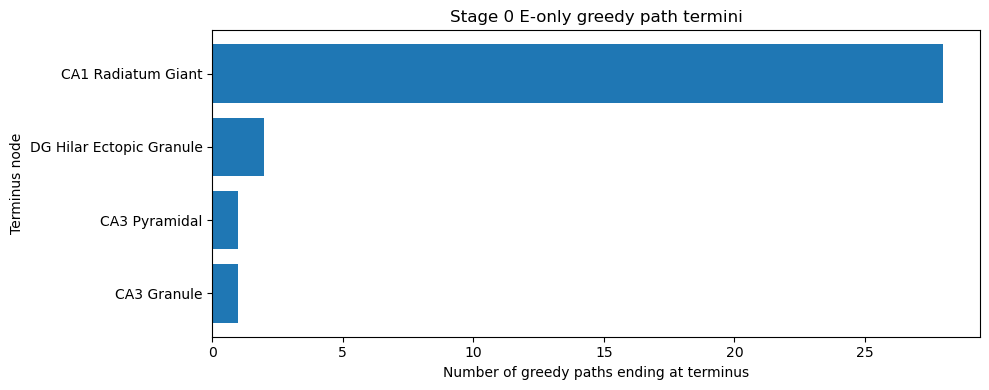

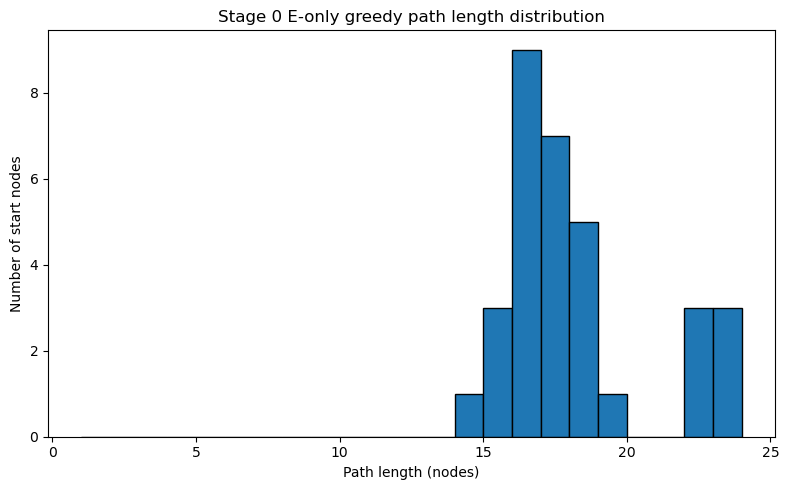

In [10]:
# ============================================================================
# Section 5 — Stage 0 exports and plots
# ============================================================================

stage0_paths_df.to_csv(OUTPUT_DIR / 'stage0_greedy_paths.csv', index=False)
stage0_edges_df.to_csv(OUTPUT_DIR / 'stage0_greedy_edges.csv', index=False)
stage0_skips_df.to_csv(OUTPUT_DIR / 'stage0_skipped_revisits.csv', index=False)
print('Saved Stage 0 tables.')

# Terminus distribution.
terminus_counts_0 = stage0_paths_df['terminus'].value_counts()
plt.figure(figsize=(10, max(4, 0.35 * len(terminus_counts_0))))
plt.barh(terminus_counts_0.index.astype(str), terminus_counts_0.values)
plt.xlabel('Number of greedy paths ending at terminus')
plt.ylabel('Terminus node')
plt.title('Stage 0 E-only greedy path termini')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage0_terminus_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Path length distribution.
plt.figure(figsize=(8, 5))
max_len = int(stage0_paths_df['path_length_nodes'].max())
plt.hist(stage0_paths_df['path_length_nodes'], bins=range(1, max_len + 2), edgecolor='black')
plt.xlabel('Path length (nodes)')
plt.ylabel('Number of start nodes')
plt.title('Stage 0 E-only greedy path length distribution')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage0_path_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


---
# Stage 1 — Inhibitory Modulation

## Section 6 — Stage 1a: Alternating E/I/E greedy tree

Stage 1a asks a different question from Stage 0:

**If inhibitory nodes are allowed into the greedy traversal, how far can an alternating `E → I → E` path go before it terminates?**

This is a structural walk through the actual signed graph:

`E_current → I_mediator → E_target → I_mediator → E_target ...`

Greedy rule:

1. From the current E node, choose the strongest available positive `E→I` edge.
2. From that I node, choose the strongest available inhibitory `I→E` target, using `|I→E|` as inhibitory magnitude.
3. Avoid revisiting E nodes and I nodes by default.
4. Continue until no eligible next `E→I→E` cycle is available.

***Note:***  This is still not a spiking or firing-rate simulation. It is a controlled structural traversal that directly includes inhibitory mediators rather than inventing a penalty term.

In [11]:
# ============================================================================
# Section 6 — Stage 1a: Alternating E/I/E greedy tree
# ============================================================================

def alternating_eie_greedy_tree(
    start_E, W_EI_pos, W_IE_inhib_mag,
    max_cycles=None, avoid_revisit_E=True, avoid_revisit_I=True,
):
    """
    Greedy alternating E/I/E path.
    At each step: E_current -> strongest unvisited I mediator ->
    strongest unvisited E target.
    Step record fields: E_source, I_mediator, E_target,
      E_to_I_weight, I_to_E_weight, bottleneck_weight, geometric_mean_weight.
    These are structural descriptors, not firing-rate values.
    """
    assert start_E in W_EI_pos.index, f'{start_E} not in W_EI_pos.index.'
    if max_cycles is None:
        max_cycles = min(W_EI_pos.shape[0] - 1, W_EI_pos.shape[1])

    visited_E, visited_I = {start_E}, set()
    E_sequence, records = [start_E], []
    current_E, terminated_because = start_E, None

    for cycle in range(max_cycles):
        ei_row = W_EI_pos.loc[current_E]
        ei_row = ei_row[ei_row > 0].sort_values(ascending=False)
        chosen_I = next(
            (n for n in ei_row.index if not (avoid_revisit_I and n in visited_I)), None
        )
        if chosen_I is None:
            terminated_because = 'no_available_positive_E_to_I_edge'
            break
        e_to_i_weight = float(ei_row[chosen_I])

        ie_row = W_IE_inhib_mag.loc[chosen_I]
        ie_row = ie_row[ie_row > 0].sort_values(ascending=False)
        chosen_E = next(
            (n for n in ie_row.index if not (avoid_revisit_E and n in visited_E)), None
        )
        if chosen_E is None:
            terminated_because = 'no_available_unvisited_inhibitory_I_to_E_target'
            break
        i_to_e_weight = float(ie_row[chosen_E])

        visited_I.add(chosen_I)
        visited_E.add(chosen_E)
        records.append({
            'cycle':                 cycle,
            'E_source':              current_E,
            'I_mediator':            chosen_I,
            'E_target':              chosen_E,
            'E_to_I_weight':         e_to_i_weight,
            'I_to_E_weight':         i_to_e_weight,
            'bottleneck_weight':     min(e_to_i_weight, i_to_e_weight),
            'geometric_mean_weight': np.sqrt(e_to_i_weight * i_to_e_weight),
        })
        E_sequence.append(chosen_E)
        current_E = chosen_E
    else:
        terminated_because = 'max_cycles_reached'

    return {
        'start_E':            start_E,
        'terminus_E':         E_sequence[-1],
        'n_cycles':           len(records),
        'terminated_because': terminated_because,
        'steps':              records,
    }


alternating_results = [
    alternating_eie_greedy_tree(n, W_EI_pos, W_IE_inhib_mag)
    for n in exc_nodes
]

# Build alternating_paths_df once with stage0-compatible column names.
# path_length_nodes = 1 start E + n_cycles I nodes + n_cycles E targets.
# cumulative_weight = sum(E->I weights) - sum(I->E weights).
alternating_paths_df = pd.DataFrame([
    {
        'start_node':        r['start_E'],
        'terminus':          r['terminus_E'],
        'path_length_nodes': 1 + 2 * r['n_cycles'],
        'n_cycles':          r['n_cycles'],
        'cumulative_weight': (
            sum(s['E_to_I_weight'] for s in r['steps'])
            - sum(s['I_to_E_weight'] for s in r['steps'])
        ),
        'terminated_because': r['terminated_because'],
        'path_string': ' -> '.join(
            [r['start_E']] + [
                node
                for s in r['steps']
                for node in (s['I_mediator'], s['E_target'])
            ]
        ),
    }
    for r in alternating_results
])

alternating_steps_df = pd.DataFrame([
    {'start_node': r['start_E'], **s}
    for r in alternating_results
    for s in r['steps']
])

no_ei_count = int((alternating_paths_df['n_cycles'] == 0).sum())
print('Stage 1a complete')
print(f'Start nodes analyzed:         {len(alternating_paths_df)}')
print(f'Could not initiate (no E->I): {no_ei_count}')
print(f'Total E->I->E steps logged:   {len(alternating_steps_df)}')
print(f'Unique termini:               {alternating_paths_df["terminus"].nunique()}')
print()
display(alternating_paths_df.sort_values('path_length_nodes', ascending=False))

display(
    alternating_paths_df["terminus"]
    .value_counts()
    .rename_axis("terminus")
    .reset_index(name="n_paths")
)

Stage 1a complete
Start nodes analyzed:         32
Could not initiate (no E->I): 8
Total E->I->E steps logged:   58
Unique termini:               13



,start_node,terminus,path_length_nodes,n_cycles,cumulative_weight,terminated_because,path_string
16,EC LIII V Bipolar Pyramidal,CA3c Pyramidal,7,3,2.950489e+04,no_available_unvisited_inhibitory_I_to_E_target,EC LIII V Bipolar Pyramidal -> MEC LIII Superf...
22,MEC LII III Pyramidal Multiform,CA3c Pyramidal,7,3,2.990630e+04,no_available_unvisited_inhibitory_I_to_E_target,MEC LII III Pyramidal Multiform -> MEC LIII Su...
25,MEC LIII Bipolar Complex Pyramidal,CA3c Pyramidal,7,3,2.673677e+04,no_available_unvisited_inhibitory_I_to_E_target,MEC LIII Bipolar Complex Pyramidal -> MEC LIII...
15,EC LIII Stellate,CA3c Pyramidal,7,3,2.491758e+04,no_available_unvisited_inhibitory_I_to_E_target,EC LIII Stellate -> MEC LIII Superficial Multi...
26,MEC LIII Complex Pyramidal,CA3c Pyramidal,7,3,3.364262e+04,no_available_unvisited_inhibitory_I_to_E_target,MEC LIII Complex Pyramidal -> MEC LIII Superfi...
27,MEC LIII Multipolar Principal,CA3c Pyramidal,7,3,2.516933e+04,no_available_unvisited_inhibitory_I_to_E_target,MEC LIII Multipolar Principal -> MEC LIII Supe...
12,EC LII III Pyramidal Tripolar,CA3c Pyramidal,7,3,5.809166e+04,no_available_unvisited_inhibitory_I_to_E_target,EC LII III Pyramidal Tripolar -> MEC LIII Supe...
11,EC LI II Pyramidal Fan,DG Semilunar Granule,7,3,2.879163e+05,no_available_unvisited_inhibitory_I_to_E_target,EC LI II Pyramidal Fan -> DG Axo Axonic -> DG ...
10,EC LI II Multipolar Pyramidal,CA3c Pyramidal,7,3,4.312871e+05,no_available_unvisited_inhibitory_I_to_E_target,EC LI II Multipolar Pyramidal -> MEC LIII Supe...
23,MEC LII Oblique Pyramidal,CA3c Pyramidal,7,3,2.398903e+04,no_available_unvisited_inhibitory_I_to_E_target,MEC LII Oblique Pyramidal -> MEC LIII Superfic...


,terminus,n_paths
0,CA3c Pyramidal,12
1,DG Semilunar Granule,5
2,SUB CA1 Projecting Pyramidal,4
3,CA1 Radiatum Giant,2
4,CA1 Pyramidal,1
5,DG Granule,1
6,EC LIV VI Deep Multipolar Principal,1
7,EC LV Deep Pyramidal,1
8,LEC LIII Complex Pyramidal,1
9,LEC LIII Multipolar Principal,1


Mean path length (nodes):   4.62
Median path length (nodes): 5.00
Max path length (nodes):    7

Termination reasons:


,terminated_because,n_paths
0,no_available_unvisited_inhibitory_I_to_E_target,25
1,no_available_positive_E_to_I_edge,7



Most frequently selected inhibitory mediators:


,I_mediator,n_times_selected
0,MEC LIII Superficial Multipolar Interneuron,11
1,MEC LIII Superficial Trilayered Interneuron,11
2,CA3 Basket,10
3,DG AIPRIM,6
4,DG Axo Axonic,6
5,DG HICAP,5
6,CA1 Trilaminar,4
7,CA1 Horizontal Basket,2
8,CA1 Perforant Path Associated,2
9,CA3 Lucidum ORAX,1



Most frequently reached E targets:


,E_target,n_times_reached
0,CA3c Pyramidal,11
1,MEC LIII Bipolar Complex Pyramidal,10
2,MEC LII Stellate,10
3,DG Hilar Ectopic Granule,5
4,DG Semilunar Granule,5
5,DG Granule,5
6,SUB CA1 Projecting Pyramidal,3
7,CA1 Pyramidal,3
8,CA1 Radiatum Giant,2
9,DG Mossy,2


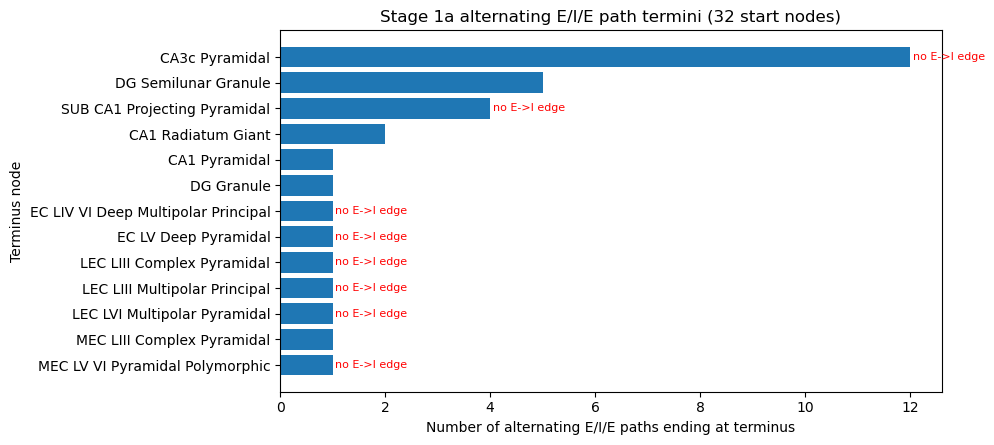

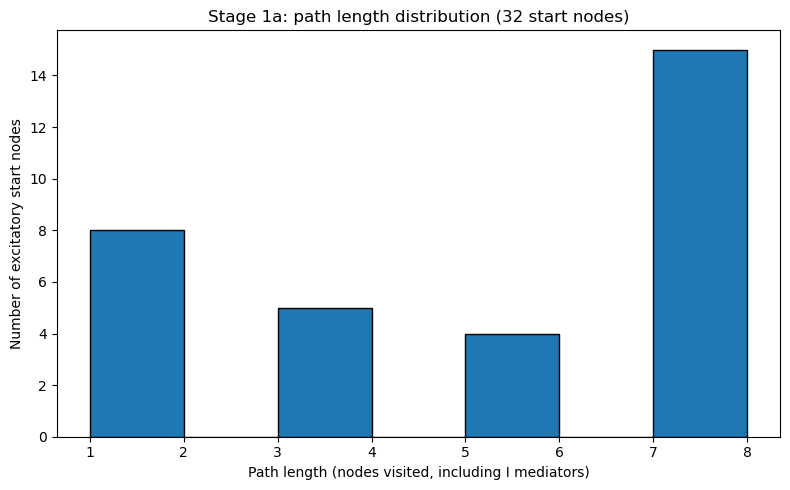

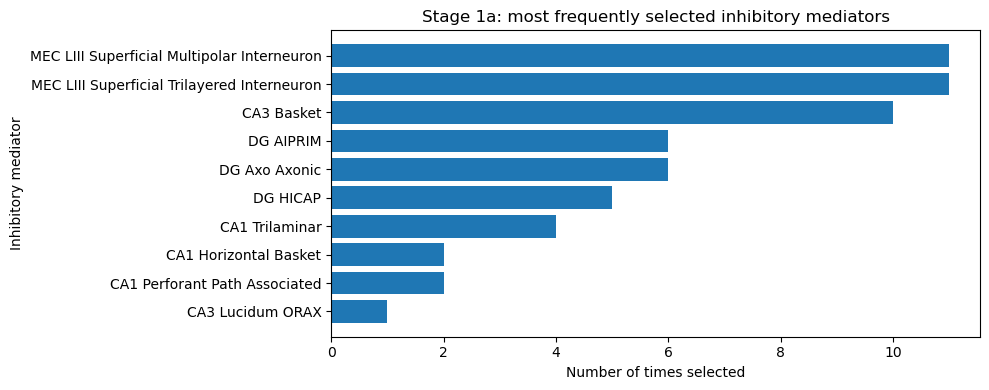

In [12]:
# ============================================================================
# Section 6b — Stage 1a statistics and plots
# ============================================================================

stage1a_termination_counts = (
    alternating_paths_df['terminated_because']
    .value_counts().rename_axis('terminated_because').reset_index(name='n_paths')
)
stage1a_i_usage = (
    alternating_steps_df['I_mediator'].value_counts()
    .rename_axis('I_mediator').reset_index(name='n_times_selected')
    if len(alternating_steps_df)
    else pd.DataFrame(columns=['I_mediator', 'n_times_selected'])
)
stage1a_e_target_usage = (
    alternating_steps_df['E_target'].value_counts()
    .rename_axis('E_target').reset_index(name='n_times_reached')
    if len(alternating_steps_df)
    else pd.DataFrame(columns=['E_target', 'n_times_reached'])
)

print(f"Mean path length (nodes):   {alternating_paths_df['path_length_nodes'].mean():.2f}")
print(f"Median path length (nodes): {alternating_paths_df['path_length_nodes'].median():.2f}")
print(f"Max path length (nodes):    {alternating_paths_df['path_length_nodes'].max()}")
print()
print('Termination reasons:')
display(stage1a_termination_counts)
print('\nMost frequently selected inhibitory mediators:')
display(stage1a_i_usage.head(20))
print('\nMost frequently reached E targets:')
display(stage1a_e_target_usage.head(20))

# Terminus distribution bar chart.
terminus_counts_1a = (
    alternating_paths_df['terminus'].value_counts()
    .rename_axis('terminus').reset_index(name='n_paths')
)
no_ei_nodes = set(alternating_paths_df[alternating_paths_df['n_cycles'] == 0]['start_node'])

plt.figure(figsize=(10, max(4, 0.35 * len(terminus_counts_1a))))
plt.barh(terminus_counts_1a['terminus'].astype(str), terminus_counts_1a['n_paths'])
plt.xlabel('Number of alternating E/I/E paths ending at terminus')
plt.ylabel('Terminus node')
plt.title(f"Stage 1a alternating E/I/E path termini ({len(alternating_paths_df)} start nodes)")
plt.gca().invert_yaxis()
for i, row in terminus_counts_1a.reset_index(drop=True).iterrows():
    if row['terminus'] in no_ei_nodes:
        plt.text(row['n_paths'] + 0.05, i, 'no E->I edge', va='center', fontsize=8, color='red')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage1a_terminus_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Path length histogram.
plt.figure(figsize=(8, 5))
max_len = int(alternating_paths_df['path_length_nodes'].max())
plt.hist(alternating_paths_df['path_length_nodes'], bins=range(1, max_len + 2), edgecolor='black')
plt.xlabel('Path length (nodes visited, including I mediators)')
plt.ylabel('Number of excitatory start nodes')
plt.title(f"Stage 1a: path length distribution ({len(alternating_paths_df)} start nodes)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage1a_path_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Top inhibitory mediators.
if len(stage1a_i_usage):
    top_i = stage1a_i_usage.head(15)
    plt.figure(figsize=(10, max(4, 0.35 * len(top_i))))
    plt.barh(top_i['I_mediator'].astype(str), top_i['n_times_selected'])
    plt.xlabel('Number of times selected')
    plt.ylabel('Inhibitory mediator')
    plt.title('Stage 1a: most frequently selected inhibitory mediators')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'stage1a_top_inhibitory_mediators.png', dpi=300, bbox_inches='tight')
    plt.show()


### All Stage 1 Greedy Trees

In [13]:
def print_stage1a_path(start_node, results=None):
    """Print the full alternating E->I->E path with signed weights."""
    if results is None:
        results = alternating_results
    match = _find_match(start_node, results, 'start_E')
    if match is None:
        return
    steps = match['steps']
    nodes, weights = [start_node], []
    for s in steps:
        nodes.append(s['I_mediator'])
        weights.append(s['E_to_I_weight'])
        nodes.append(s['E_target'])
        weights.append(-s['I_to_E_weight'])
    n_steps = len(nodes) - 1
    cum_w = sum(s['E_to_I_weight'] for s in steps) - sum(s['I_to_E_weight'] for s in steps)
    print(f"Start:    {start_node}")
    print(f"Steps:    {n_steps}  |  Terminus: {match['terminus_E']}")
    if n_steps == 0:
        print('  *** No positive E->I edge available — path could not initiate ***')
    print()
    for i, node in enumerate(nodes):
        prefix = f'  {i:>2}: '
        if i < len(nodes) - 1:
            print(f"{prefix}{node}  [w={weights[i]:+.3e}] ->")
        else:
            print(f"{prefix}{node}   [TERMINUS]")
    print(f"\n  Cumulative weight: {cum_w:.3e}")
    print(f"  Stop: {match['terminated_because']}")
    
def print_all_stage1a_paths(results=None):
    """Print Stage 1a alternating E/I/E paths for all excitatory start nodes."""
    if results is None:
        results = alternating_results
    for r in results:
        print_stage1a_path(r['start_E'], results=results)
        print()

print_all_stage1a_paths()

Start:    CA1 Pyramidal
Steps:    2  |  Terminus: SUB CA1 Projecting Pyramidal

   0: CA1 Pyramidal  [w=+8.063e+04] ->
   1: CA1 Trilaminar  [w=-1.799e+01] ->
   2: SUB CA1 Projecting Pyramidal   [TERMINUS]

  Cumulative weight: 8.061e+04
  Stop: no_available_unvisited_inhibitory_I_to_E_target

Start:    CA1 Radiatum Giant
Steps:    2  |  Terminus: CA1 Pyramidal

   0: CA1 Radiatum Giant  [w=+1.445e+03] ->
   1: CA1 Trilaminar  [w=-4.029e+01] ->
   2: CA1 Pyramidal   [TERMINUS]

  Cumulative weight: 1.405e+03
  Stop: no_available_unvisited_inhibitory_I_to_E_target

Start:    CA2 Pyramidal
Steps:    4  |  Terminus: CA1 Radiatum Giant

   0: CA2 Pyramidal  [w=+9.030e+04] ->
   1: CA1 Trilaminar  [w=-4.029e+01] ->
   2: CA1 Pyramidal  [w=+1.754e+04] ->
   3: CA1 Horizontal Basket  [w=-8.169e+00] ->
   4: CA1 Radiatum Giant   [TERMINUS]

  Cumulative weight: 1.078e+05
  Stop: no_available_unvisited_inhibitory_I_to_E_target

Start:    CA3 Granule
Steps:    2  |  Terminus: CA3c Pyramidal

  

## Section 7 — Stage 1b: E→I→E inhibitory motif enumeration

Enumerates all directed `E_source → I_node → E_target` structural motifs and
overlays them on the Stage 0 backbone. Produces four variables consumed by
Stage 1c and Section 9 exports:

- `stage1_triplets_df` — one row per unique E→I→E triplet
- `stage1_pair_df` — one row per unique (E_source, E_target) pair with mediator count
- `stage1_transition_df` — path-weighted Stage 0 transitions joined to inhibitory data
- `unique_stage0_edges` — deduplicated Stage 0 edges joined to inhibitory data

**`n_I_mediators`** is the primary architectural metric: a high count means many
inhibitory interneurons can relay influence between the same excitatory source and
target. Weight summaries are included for ranking only. See Appendix for full
triplet tables and mediator distribution plots.

In [14]:
# ============================================================================
# Section 7 — Stage 1b: E→I→E motif enumeration and Stage 0 overlay
# ============================================================================

def build_eie_triplets(W_EI_pos, W_IE_inhib_mag):
    """
    Build all E_source -> I_node -> E_target triplets via stack + merge.
    Scales cleanly to any matrix size.
    """
    ei = (
        W_EI_pos.stack().pipe(lambda s: s[s > 0])
        .rename('E_to_I_weight').reset_index()
    )
    ei.columns = ['E_source', 'I_node', 'E_to_I_weight']

    ie = (
        W_IE_inhib_mag.stack().pipe(lambda s: s[s > 0])
        .rename('I_to_E_weight').reset_index()
    )
    ie.columns = ['I_node', 'E_target', 'I_to_E_weight']

    if ei.empty or ie.empty:
        return pd.DataFrame(columns=[
            'E_source','I_node','E_target',
            'E_to_I_weight','I_to_E_weight',
            'bottleneck_weight','geometric_mean_weight','log10_two_step_weight',
        ])

    df = ei.merge(ie, on='I_node')
    df['bottleneck_weight']      = df[['E_to_I_weight','I_to_E_weight']].min(axis=1)
    df['geometric_mean_weight']  = np.sqrt(df['E_to_I_weight'] * df['I_to_E_weight'])
    df['log10_two_step_weight']  = np.log10(df['E_to_I_weight']) + np.log10(df['I_to_E_weight'])
    return df[['E_source','I_node','E_target',
               'E_to_I_weight','I_to_E_weight',
               'bottleneck_weight','geometric_mean_weight','log10_two_step_weight']]


assert set(exc_nodes).issubset(set(W_EI_pos.index))
assert set(inh_nodes).issubset(set(W_EI_pos.columns))
assert set(inh_nodes).issubset(set(W_IE_inhib_mag.index))
assert set(exc_nodes).issubset(set(W_IE_inhib_mag.columns))

stage1_triplets_df = build_eie_triplets(W_EI_pos, W_IE_inhib_mag)

# Validate E/I classification.
if len(stage1_triplets_df):
    assert not sorted(set(stage1_triplets_df['E_source']) - set(exc_nodes)), 'Non-E sources in triplets'
    assert not sorted(set(stage1_triplets_df['I_node'])   - set(inh_nodes)), 'Non-I mediators in triplets'
    assert not sorted(set(stage1_triplets_df['E_target']) - set(exc_nodes)), 'Non-E targets in triplets'

# Summarise by (E_source, E_target) pair.
if len(stage1_triplets_df):
    stage1_pair_df = (
        stage1_triplets_df
        .groupby(['E_source','E_target'], as_index=False)
        .agg(
            n_I_mediators=         ('I_node',              'nunique'),
            I_mediators=           ('I_node',              lambda x: '; '.join(sorted(map(str, set(x))))),
            mean_E_to_I_weight=    ('E_to_I_weight',       'mean'),
            mean_I_to_E_weight=    ('I_to_E_weight',       'mean'),
            max_bottleneck_weight= ('bottleneck_weight',   'max'),
            mean_bottleneck_weight=('bottleneck_weight',   'mean'),
            max_geometric_mean_weight= ('geometric_mean_weight','max'),
            mean_geometric_mean_weight=('geometric_mean_weight','mean'),
        )
    )
else:
    stage1_pair_df = pd.DataFrame(columns=[
        'E_source','E_target','n_I_mediators','I_mediators',
        'mean_E_to_I_weight','mean_I_to_E_weight',
        'max_bottleneck_weight','mean_bottleneck_weight',
        'max_geometric_mean_weight','mean_geometric_mean_weight',
    ])

# Stage 0 overlay: path-weighted transitions joined to inhibitory pair data.
stage1_transition_df = (
    stage0_edges_df
    .rename(columns={'from_node':'E_source','to_node':'stage0_next'})
    .merge(
        stage1_pair_df.rename(columns={'E_target':'stage0_next'}),
        on=['E_source','stage0_next'], how='left',
    )
)

if len(stage1_pair_df):
    best_alt = (
        stage1_pair_df
        .sort_values(['n_I_mediators','max_bottleneck_weight'], ascending=False)
        .groupby('E_source', as_index=False).first()
        [['E_source','E_target','n_I_mediators']]
        .rename(columns={'E_target':'most_mediated_target_from_source',
                         'n_I_mediators':'most_mediated_target_n_I'})
    )
    stage1_transition_df = stage1_transition_df.merge(best_alt, on='E_source', how='left')
else:
    stage1_transition_df['most_mediated_target_from_source'] = None
    stage1_transition_df['most_mediated_target_n_I'] = 0

stage1_transition_df['embedded_in_inhibitory_motif'] = stage1_transition_df['n_I_mediators'].notna()
stage1_transition_df['n_I_mediators_to_next'] = stage1_transition_df['n_I_mediators'].fillna(0).astype(int)
stage1_transition_df['I_mediators'] = stage1_transition_df['I_mediators'].fillna('')

n_total_transitions = len(stage1_transition_df)
n_embedded = int(stage1_transition_df['embedded_in_inhibitory_motif'].sum())
pct_embedded = 100 * n_embedded / n_total_transitions if n_total_transitions else 0

# Unique-edge overlay.
unique_stage0_edges = (
    stage0_edges_df[['from_node','to_node']].drop_duplicates()
    .rename(columns={'from_node':'E_source','to_node':'E_target'})
    .merge(stage1_pair_df, on=['E_source','E_target'], how='left')
)
unique_stage0_edges['has_source_specific_inhibitory_motif'] = unique_stage0_edges['n_I_mediators'].notna()
unique_stage0_edges['n_I_mediators'] = unique_stage0_edges['n_I_mediators'].fillna(0).astype(int)
unique_stage0_edges['I_mediators']   = unique_stage0_edges['I_mediators'].fillna('')
for col in ['mean_E_to_I_weight','mean_I_to_E_weight',
            'max_bottleneck_weight','mean_bottleneck_weight',
            'max_geometric_mean_weight','mean_geometric_mean_weight']:
    unique_stage0_edges[col] = unique_stage0_edges[col].fillna(0.0)

print(f'Stage 1b: {len(stage1_triplets_df)} unique E->I->E triplets')
print(f'Unique (E_source, E_target) pairs with >=1 mediator: {len(stage1_pair_df)}')
print(f'Stage 0 transitions embedded in inhibitory motif: {n_embedded}/{n_total_transitions} ({pct_embedded:.1f}%)')
print(f'Unique Stage 0 edges embedded: '
      f'{int(unique_stage0_edges["has_source_specific_inhibitory_motif"].sum())}/{len(unique_stage0_edges)}')


Stage 1b: 1341 unique E->I->E triplets
Unique (E_source, E_target) pairs with >=1 mediator: 370
Stage 0 transitions embedded in inhibitory motif: 329/534 (61.6%)
Unique Stage 0 edges embedded: 51/75


## Section 8 — Stage 1c: E→E backbone with inhibitory flanking

Stage 1c annotates the Stage 0 E-only greedy path with the inhibitory microcircuit
structure flanking each consecutive E→E step, drawn from Stage 1b triplets.

For each E→E transition in the Stage 0 path:

- The direct **w_EE** edge weight is recorded.
- All **I mediators** connecting that same `(E_source, E_target)` pair are listed,
  each with their raw **w_IE** value (negative, from `W_IE_signed`) and **w_EI**.
- Two cumulative columns run side by side:
  - **cum_EE** — running sum of E→E weights only.
  - **cum_EI** — running signed sum: each step adds `w_EE + Σ(w_IE)` for all
    simultaneous I mediators. `w_IE` is raw negative so it subtracts naturally.

The gap between `cum_EE` and `cum_EI` at any node reflects net inhibitory load
accumulated along the path to that point.

- `print_stage1c_path(name)` — annotated path printed to console.
- `build_stage1c_df(name)` — tidy DataFrame, one row per E node or I mediator line.
- `build_all_stage1c_df()` — full DataFrame across all excitatory start nodes.

In [15]:
# ============================================================================
# Section 8b — Stage 1c: E->E backbone with inhibitory flanking
# ============================================================================

def _get_mediators_for_pair(e_source, e_target, triplets_df, W_IE_signed):
    """
    Return list of dicts for all I mediators between e_source and e_target.
    w_IE is raw negative value from W_IE_signed, not the magnitude.
    Sorted by w_IE ascending (most negative = strongest suppression first).
    """
    mask = (
        (triplets_df['E_source'] == e_source) &
        (triplets_df['E_target'] == e_target)
    )
    mediators = [
        {
            'I_node': row['I_node'],
            'w_EI':   float(row['E_to_I_weight']),
            'w_IE':   float(W_IE_signed.loc[row['I_node'], e_target]),
            'net_I':  float(row['E_to_I_weight']) + float(W_IE_signed.loc[row['I_node'], e_target]),
        }
        for _, row in triplets_df[mask].iterrows()
    ]
    mediators.sort(key=lambda x: x['w_IE'])
    return mediators


def build_stage1c_df(start_node, results=None, triplets_df=None, W_IE_signed_mat=None):
    """
    Build tidy Stage 1c DataFrame for one start node.

    Row types:
      'E_node'     - an E node in the Stage 0 path
      'I_mediator' - an I mediator flanking the preceding E->E step

    Columns: start_node, step, row_type, node,
             w_EE, w_EI, w_IE, net_I, cum_EE, cum_EI
    """
    if results         is None: results         = stage0_results
    if triplets_df     is None: triplets_df     = stage1_triplets_df
    if W_IE_signed_mat is None: W_IE_signed_mat = W_IE_signed

    match = _find_match(start_node, results, 'start_node')
    if match is None:
        return pd.DataFrame()

    path, edge_records = match['path'], match['edge_records']
    rows, cum_EE, cum_EI = [], 0.0, 0.0

    for i, node in enumerate(path):
        w_ee = edge_records[i]['weight'] if i < len(edge_records) else None

        rows.append({
            'step':     i,
            'row_type': 'E_node',
            'node':     node,
            'w_EE':     w_ee,
            'w_EI':     None,
            'w_IE':     None,
            'net_I':    None,
            'cum_EE':   cum_EE,
            'cum_EI':   cum_EI,
        })

        if i < len(edge_records):
            e_target  = path[i + 1]
            mediators = _get_mediators_for_pair(
                node, e_target, triplets_df, W_IE_signed_mat
            )
            sum_w_ie = sum(m['w_IE'] for m in mediators)  # negative
            cum_EE  += w_ee
            cum_EI  += w_ee + sum_w_ie

            for m in mediators:
                rows.append({
                    'step':     i,
                    'row_type': 'I_mediator',
                    'node':     m['I_node'],
                    'w_EE':     None,
                    'w_EI':     m['w_EI'],
                    'w_IE':     m['w_IE'],
                    'net_I':    m['net_I'],
                    'cum_EE':   None,
                    'cum_EI':   None,
                })

    df = pd.DataFrame(rows)
    df['start_node'] = start_node
    return df[['start_node','step','row_type','node',
               'w_EE','w_EI','w_IE','net_I','cum_EE','cum_EI']]


def print_stage1c_path(start_node, results=None,
                        triplets_df=None, W_IE_signed_mat=None):
    """
    Print the Stage 0 E->E backbone annotated with inhibitory flanking.
    Two running totals shown side by side: cum_EE (E only) and cum_EI (signed).
    """
    if results         is None: results         = stage0_results
    if triplets_df     is None: triplets_df     = stage1_triplets_df
    if W_IE_signed_mat is None: W_IE_signed_mat = W_IE_signed

    df = build_stage1c_df(start_node, results, triplets_df, W_IE_signed_mat)
    if df.empty:
        return

    match    = _find_match(start_node, results, 'start_node')
    terminus = match['terminus']
    n_steps  = match['n_edges']

    print(f'Start:  {start_node}')
    print(f'Steps:  {n_steps}  |  Terminus: {terminus}')
    print()
    print(f"  {'Step':<5}  {'Node':<45}  {'Synaptic path':<26}  {'cum_EE':>12}  {'cum_EI':>12}")
    print(f"  {'-'*5}  {'-'*45}  {'-'*26}  {'-'*12}  {'-'*12}")

    e_rows = df[df['row_type'] == 'E_node'].reset_index(drop=True)

    for _, erow in e_rows.iterrows():
        step    = int(erow['step'])
        is_term = (step == n_steps)
        wee_str = '[TERMINUS]' if is_term else f"w_EE={erow['w_EE']:+.3e}"
        cum_EE  = erow['cum_EE']
        cum_EI  = erow['cum_EI']
        print(f"  {step:<5}  {erow['node']:<45}  {wee_str:<26}  {cum_EE:>+12.3e}  {cum_EI:>+12.3e}")

        i_rows = df[(df['row_type'] == 'I_mediator') & (df['step'] == step)]
        for _, irow in i_rows.iterrows():
            i_str = f"w_EI={irow['w_EI']:+.3e}  w_IE={irow['w_IE']:+.3e}  net={irow['net_I']:+.3e}"
            print(f"  {'':5}  {'  via ' + str(irow['node']):<45}  {i_str}")


def build_all_stage1c_df(results=None, triplets_df=None, W_IE_signed_mat=None):
    """Build Stage 1c DataFrame across all excitatory start nodes."""
    if results         is None: results         = stage0_results
    if triplets_df     is None: triplets_df     = stage1_triplets_df
    if W_IE_signed_mat is None: W_IE_signed_mat = W_IE_signed
    return pd.concat(
        [build_stage1c_df(r['start_node'], results, triplets_df, W_IE_signed_mat)
         for r in results],
        ignore_index=True,
    )


# -- Example call ------------------------------------------------------------
print_stage1c_path('EC LIII Stellate')
print()

# Build and export full DataFrame.
stage1c_df = build_all_stage1c_df()
stage1c_df.to_csv(
    OUTPUT_DIR / 'stage1c_backbone_with_inhibitory_flanking.csv', index=False
)
print(f'stage1c_df: {len(stage1c_df)} rows')
print('Saved: stage1c_backbone_with_inhibitory_flanking.csv')


Start:  EC LIII Stellate
Steps:  22  |  Terminus: CA1 Radiatum Giant

  Step   Node                                           Synaptic path                     cum_EE        cum_EI
  -----  ---------------------------------------------  --------------------------  ------------  ------------
  0      EC LIII Stellate                               w_EE=+1.658e+02               +0.000e+00    +0.000e+00
           via MEC LIII Superficial Multipolar Interneuron  w_EI=+1.778e+03  w_IE=-3.857e+02  net=+1.392e+03
           via MEC LIII Superficial Trilayered Interneuron  w_EI=+4.333e+01  w_IE=-1.868e+02  net=-1.434e+02
  1      MEC LIII Complex Pyramidal                     w_EE=+1.193e+03               +1.658e+02    -4.067e+02
           via MEC LIII Superficial Trilayered Interneuron  w_EI=+6.492e+02  w_IE=-2.322e+02  net=+4.170e+02
           via MEC LIII Superficial Multipolar Interneuron  w_EI=+1.050e+04  w_IE=-1.072e+02  net=+1.040e+04
  2      MEC LII Stellate                         

In [16]:
for r in stage0_results:
    print_stage1c_path(r["start_node"])
    print()

Start:  CA1 Pyramidal
Steps:  15  |  Terminus: CA1 Radiatum Giant

  Step   Node                                           Synaptic path                     cum_EE        cum_EI
  -----  ---------------------------------------------  --------------------------  ------------  ------------
  0      CA1 Pyramidal                                  w_EE=+1.356e+04               +0.000e+00    +0.000e+00
  1      MEC LV VI Pyramidal Polymorphic                w_EE=+8.678e+01               +1.356e+04    +1.356e+04
  2      EC LIV VI Deep Multipolar Principal            w_EE=+2.246e+03               +1.365e+04    +1.365e+04
  3      LEC LVI Multipolar Pyramidal                   w_EE=+3.040e+02               +1.590e+04    +1.590e+04
  4      LEC LIII Multipolar Principal                  w_EE=+5.561e+02               +1.620e+04    +1.620e+04
  5      LEC LIII Complex Pyramidal                     w_EE=+5.381e+02               +1.676e+04    +1.676e+04
  6      EC LIII Pyramidal Stellate          

## Section 9 — Export all Stage 0, Stage 1a, and Stage 1b results

In [17]:
# ============================================================================
# Section 9 — Export all results
# ============================================================================

files_to_save = {
    # Stage 0
    'stage0_greedy_paths.csv':                              stage0_paths_df,
    'stage0_greedy_edges.csv':                              stage0_edges_df,
    'stage0_skipped_revisits.csv':                          stage0_skips_df,
    # Stage 1a
    'stage1a_alternating_eie_paths.csv':                    alternating_paths_df,
    'stage1a_alternating_eie_steps.csv':                    alternating_steps_df,
    'stage1a_termination_counts.csv':                       stage1a_termination_counts,
    'stage1a_inhibitory_mediator_usage.csv':                stage1a_i_usage,
    'stage1a_E_target_usage.csv':                           stage1a_e_target_usage,
    # Stage 1b
    'stage1b_eie_triplets.csv':                             stage1_triplets_df,
    'stage1b_source_target_mediation.csv':                  stage1_pair_df,
    'stage1b_overlay_on_stage0_transitions.csv':            stage1_transition_df,
    'stage1b_unique_stage0_edges_with_inhibitory_motifs.csv': unique_stage0_edges,
    'stage1c_backbone_with_inhibitory_flanking.csv':          stage1c_df,
}

for filename, df in files_to_save.items():
    df.to_csv(OUTPUT_DIR / filename, index=False)
    print(f'Saved: {filename}')

summary_file = OUTPUT_DIR / 'stage01_summary.txt'
with open(summary_file, 'w', encoding='utf-8') as f:
    f.write('STAGE 0 + STAGE 1A + STAGE 1B SUMMARY\n')
    f.write('=' * 70 + '\n\n')
    f.write('Stage 0: E-only greedy scaffold\n')
    f.write(f'  E nodes analyzed:      {len(exc_nodes)}\n')
    f.write(f'  Positive E->E edges:   {n_EE_pos}\n')
    f.write(f'  Unique termini:        {stage0_paths_df["terminus"].nunique()}\n')
    top0 = stage0_paths_df['terminus'].value_counts()
    f.write(f'  Most common terminus:  {top0.index[0]} (n={top0.iloc[0]})\n')
    f.write('\nStage 1a: alternating E/I/E greedy tree\n')
    f.write(f'  Start nodes analyzed:          {len(alternating_paths_df)}\n')
    f.write(f'  Could not initiate (no E->I):  {no_ei_count}\n')
    f.write(f'  Mean path length (nodes):      {alternating_paths_df["path_length_nodes"].mean():.2f}\n')
    f.write(f'  Unique termini:                {alternating_paths_df["terminus"].nunique()}\n')
    top1 = alternating_paths_df['terminus'].value_counts()
    f.write(f'  Most common terminus:          {top1.index[0]} (n={top1.iloc[0]})\n')
    f.write('\nStage 1b: source-specific E->I->E inhibitory motifs\n')
    f.write(f'  Unique E->I->E triplets:       {len(stage1_triplets_df)}\n')
    f.write(f'  Unique E_src->E_tgt pairs:     {len(stage1_pair_df)}\n')
    f.write(f'  Stage 0 transitions embedded:  {n_embedded}/{n_total_transitions} ({pct_embedded:.1f}%)\n')
    n_emb_uniq = int(unique_stage0_edges['has_source_specific_inhibitory_motif'].sum())
    f.write(f'  Unique Stage 0 edges embedded: {n_emb_uniq}/{len(unique_stage0_edges)}\n')
    f.write('\nCaveats:\n')
    f.write('  Stage 0 is a structural greedy scaffold, not a firing simulation.\n')
    f.write('  Stage 1a is a greedy graph heuristic, not a spiking model.\n')
    f.write('  Stage 1b motifs are directed structural patterns, not currents.\n')
    f.write('  Mediator counts are the primary Stage 1b metric; weights are descriptive.\n')
print(f'\nSaved summary: {summary_file.name}')


Saved: stage0_greedy_paths.csv
Saved: stage0_greedy_edges.csv
Saved: stage0_skipped_revisits.csv
Saved: stage1a_alternating_eie_paths.csv
Saved: stage1a_alternating_eie_steps.csv
Saved: stage1a_termination_counts.csv
Saved: stage1a_inhibitory_mediator_usage.csv
Saved: stage1a_E_target_usage.csv
Saved: stage1b_eie_triplets.csv
Saved: stage1b_source_target_mediation.csv
Saved: stage1b_overlay_on_stage0_transitions.csv
Saved: stage1b_unique_stage0_edges_with_inhibitory_motifs.csv
Saved: stage1c_backbone_with_inhibitory_flanking.csv

Saved summary: stage01_summary.txt


## Section 10 — Compact final visualization

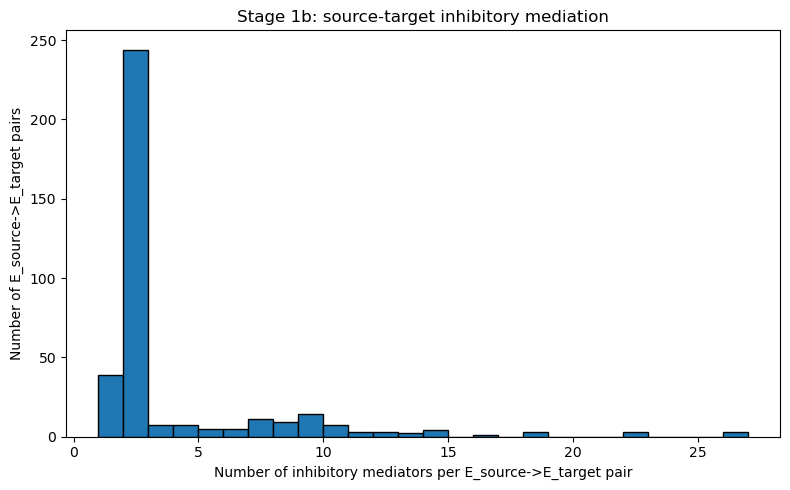

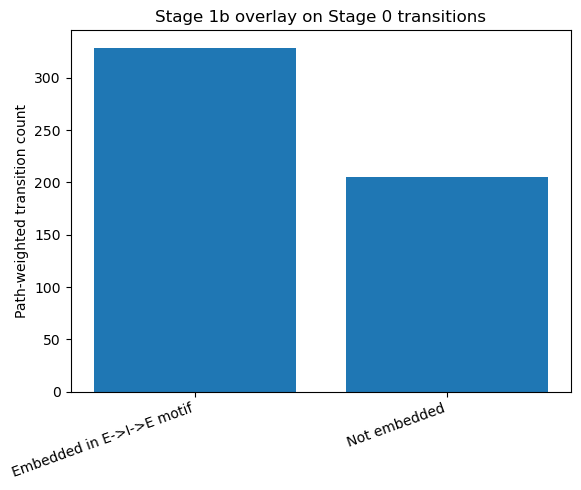

All plots saved to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/Ascoli Lab Rotation/Final Project/outputs/stage01_corrected

Plot inventory:
  final_section8_alternating_eie_path_lengths.png
  final_stage0_top_termini.png
  final_stage1_inhibitory_mediator_count_distribution.png
  final_stage1_overlay_counts.png
  final_stage1_sidechain_strength_distribution.png
  final_stage1a_alternating_eie_path_lengths.png
  stage0_canonical_pathway_coverage.png
  stage0_ee_directed_graph.png
  stage0_path_length_distribution.png
  stage0_path_length_distribution_corrected.png
  stage0_terminus_distribution.png
  stage0_terminus_distribution_corrected.png
  stage1a_alternating_eie_path_depth_distribution.png
  stage1a_path_length_distribution.png
  stage1a_terminus_distribution.png
  stage1a_top_inhibitory_mediators.png
  stage1b_inhibitory_mediator_count_distribution.png
  stage1b_overlay_counts.png


In [18]:
# ============================================================================
# Section 10 — Stage 1b final visualization
# ============================================================================
# Stage 0 and Stage 1a plots are already saved in Sections 5 and 6b.
# This section covers the two Stage 1b summary plots.

# Inhibitory mediator count distribution per source-target pair.
if len(stage1_pair_df):
    plt.figure(figsize=(8, 5))
    bins = range(1, int(stage1_pair_df['n_I_mediators'].max()) + 2)
    plt.hist(stage1_pair_df['n_I_mediators'], bins=bins, edgecolor='black')
    plt.xlabel('Number of inhibitory mediators per E_source->E_target pair')
    plt.ylabel('Number of E_source->E_target pairs')
    plt.title('Stage 1b: source-target inhibitory mediation')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'stage1b_inhibitory_mediator_count_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# Embedding of Stage 0 transitions in E->I->E motifs.
plt.figure(figsize=(6, 5))
plt.bar(
    ['Embedded in E->I->E motif', 'Not embedded'],
    [n_embedded, n_total_transitions - n_embedded]
)
plt.ylabel('Path-weighted transition count')
plt.title('Stage 1b overlay on Stage 0 transitions')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage1b_overlay_counts.png', dpi=300, bbox_inches='tight')
plt.show()

print('All plots saved to:', OUTPUT_DIR)
print()
print('Plot inventory:')
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {p.name}')


# Miscellaneous

## Section 11 — Interpretation guardrails

Use these guardrails when presenting the results.

1. **Stage 0 is an E-only scaffold**, not a full functional model. It answers which positive E→E route dominates under a greedy rule.
2. **Stage 1a is an alternating structural traversal.** It directly includes inhibitory nodes in the walk, but it remains a greedy graph heuristic rather than a spiking or firing-rate simulation.
3. **Stage 1b E→I→E entries are source-specific structural motifs**, not simulated inhibitory firing rates.
4. **Embedded in an inhibitory motif means exact source-target overlap:** a direct Stage 0 `E_source→E_target` edge also has at least one `E_source→I_node→E_target` path.
5. **Path-weighted counts are not unique-edge counts.** A transition appearing in many greedy paths will be counted repeatedly in path-weighted summaries.
6. **Mediator counts are the strongest Stage 1b metric.** `n_I_mediators` for a given `E_source→E_target` pair tells you how many distinct inhibitory interneurons can relay influence between those two excitatory nodes. A high count indicates the direct E→E backbone edge is architecturally paired with a rich local inhibitory scaffold — not that those interneurons are simultaneously active. Weight summaries are descriptive and should be used for ranking/inspection, not for biophysical claims.
7. **The strongest interpretation is architectural:** the dominant E-only backbone is locally paired with inhibitory microcircuit motifs, which is consistent with brain-network motif concepts and E/I circuit organization.

# Appendix - Additional Tables
## All Excitatory Nodes

In [19]:
for node in exc_nodes:
    print(node)

CA1 Pyramidal
CA1 Radiatum Giant
CA2 Pyramidal
CA3 Granule
CA3 Pyramidal
CA3c Pyramidal
DG Granule
DG Hilar Ectopic Granule
DG Mossy
DG Semilunar Granule
EC LI II Multipolar Pyramidal
EC LI II Pyramidal Fan
EC LII III Pyramidal Tripolar
EC LIII Pyramidal
EC LIII Pyramidal Stellate
EC LIII Stellate
EC LIII V Bipolar Pyramidal
EC LIV VI Deep Multipolar Principal
EC LV Deep Pyramidal
LEC LIII Complex Pyramidal
LEC LIII Multipolar Principal
LEC LVI Multipolar Pyramidal
MEC LII III Pyramidal Multiform
MEC LII Oblique Pyramidal
MEC LII Stellate
MEC LIII Bipolar Complex Pyramidal
MEC LIII Complex Pyramidal
MEC LIII Multipolar Principal
MEC LV Pyramidal
MEC LV Superficial Pyramidal
MEC LV VI Pyramidal Polymorphic
SUB CA1 Projecting Pyramidal


## Stage 0 Greedy Trees
### EC Region

In [20]:
for r in stage0_results:
    if r['start_node'].startswith('EC'):
        print_stage0_path(r['start_node'])
        print()

Start:    EC LI II Multipolar Pyramidal
Steps:    14  |  Terminus: CA1 Radiatum Giant

   0: EC LI II Multipolar Pyramidal  [w=3.070e+04] ->
   1: MEC LIII Bipolar Complex Pyramidal  [w=8.612e+02] ->
   2: MEC LIII Complex Pyramidal  [w=1.193e+03] ->
   3: MEC LII Stellate  [w=1.964e+04] ->
   4: CA3 Granule  [w=2.281e+00] ->
   5: CA3c Pyramidal  [w=8.561e+04] ->
   6: CA1 Pyramidal  [w=1.356e+04] ->
   7: MEC LV VI Pyramidal Polymorphic  [w=8.678e+01] ->
   8: EC LIV VI Deep Multipolar Principal  [w=2.246e+03] ->
   9: LEC LVI Multipolar Pyramidal  [w=3.040e+02] ->
  10: LEC LIII Multipolar Principal  [w=5.561e+02] ->
  11: LEC LIII Complex Pyramidal  [w=5.381e+02] ->
  12: EC LIII Pyramidal Stellate  [w=3.898e+02] ->
  13: SUB CA1 Projecting Pyramidal  [w=8.288e+00] ->
  14: CA1 Radiatum Giant   [TERMINUS]

  Cumulative weight: 1.557e+05
  Stop: no_unvisited_positive_targets

Start:    EC LI II Pyramidal Fan
Steps:    15  |  Terminus: CA1 Radiatum Giant

   0: EC LI II Pyramidal Fan

### MEC Region

In [21]:
for r in stage0_results:
    if r['start_node'].startswith('MEC'):
        print_stage0_path(r['start_node'])
        print()

Start:    MEC LII III Pyramidal Multiform
Steps:    18  |  Terminus: CA1 Radiatum Giant

   0: MEC LII III Pyramidal Multiform  [w=1.304e+03] ->
   1: MEC LV VI Pyramidal Polymorphic  [w=8.678e+01] ->
   2: EC LIV VI Deep Multipolar Principal  [w=2.246e+03] ->
   3: LEC LVI Multipolar Pyramidal  [w=3.040e+02] ->
   4: LEC LIII Multipolar Principal  [w=5.561e+02] ->
   5: LEC LIII Complex Pyramidal  [w=5.381e+02] ->
   6: EC LIII Pyramidal Stellate  [w=5.351e+03] ->
   7: CA1 Pyramidal  [w=6.928e+03] ->
   8: EC LV Deep Pyramidal  [w=1.804e+02] ->
   9: EC LIII V Bipolar Pyramidal  [w=1.056e+03] ->
  10: MEC LIII Complex Pyramidal  [w=1.193e+03] ->
  11: MEC LII Stellate  [w=1.964e+04] ->
  12: CA3 Granule  [w=2.281e+00] ->
  13: CA3c Pyramidal  [w=2.442e+04] ->
  14: CA2 Pyramidal  [w=4.836e+03] ->
  15: DG Mossy  [w=2.120e+03] ->
  16: DG Hilar Ectopic Granule  [w=1.330e-02] ->
  17: CA3 Pyramidal  [w=3.037e+02] ->
  18: CA1 Radiatum Giant   [TERMINUS]

  Cumulative weight: 7.107e+04


### DG Region

In [22]:
for r in stage0_results:
    if r['start_node'].startswith('DG'):
        print_stage0_path(r['start_node'])
        print()

Start:    DG Granule
Steps:    16  |  Terminus: CA1 Radiatum Giant

   0: DG Granule  [w=4.491e+04] ->
   1: DG Mossy  [w=2.120e+03] ->
   2: DG Hilar Ectopic Granule  [w=5.506e-02] ->
   3: CA3c Pyramidal  [w=8.561e+04] ->
   4: CA1 Pyramidal  [w=1.356e+04] ->
   5: MEC LV VI Pyramidal Polymorphic  [w=8.678e+01] ->
   6: EC LIV VI Deep Multipolar Principal  [w=2.246e+03] ->
   7: LEC LVI Multipolar Pyramidal  [w=3.040e+02] ->
   8: LEC LIII Multipolar Principal  [w=5.561e+02] ->
   9: LEC LIII Complex Pyramidal  [w=5.381e+02] ->
  10: EC LIII Pyramidal Stellate  [w=6.474e+02] ->
  11: MEC LIII Complex Pyramidal  [w=1.193e+03] ->
  12: MEC LII Stellate  [w=1.964e+04] ->
  13: CA3 Granule  [w=9.420e-01] ->
  14: CA3 Pyramidal  [w=1.247e+04] ->
  15: CA2 Pyramidal  [w=2.631e+02] ->
  16: CA1 Radiatum Giant   [TERMINUS]

  Cumulative weight: 1.841e+05
  Stop: no_unvisited_positive_targets

Start:    DG Hilar Ectopic Granule
Steps:    15  |  Terminus: CA1 Radiatum Giant

   0: DG Hilar Ect

### CA3 Region

This includes CA3c Pyramidal

In [23]:
for r in stage0_results:
    if r['start_node'].startswith('CA3'):
        print_stage0_path(r['start_node'])
        print()

Start:    CA3 Granule
Steps:    15  |  Terminus: CA1 Radiatum Giant

   0: CA3 Granule  [w=2.281e+00] ->
   1: CA3c Pyramidal  [w=8.561e+04] ->
   2: CA1 Pyramidal  [w=1.356e+04] ->
   3: MEC LV VI Pyramidal Polymorphic  [w=8.678e+01] ->
   4: EC LIV VI Deep Multipolar Principal  [w=2.246e+03] ->
   5: LEC LVI Multipolar Pyramidal  [w=3.040e+02] ->
   6: LEC LIII Multipolar Principal  [w=5.561e+02] ->
   7: LEC LIII Complex Pyramidal  [w=5.381e+02] ->
   8: EC LIII Pyramidal Stellate  [w=6.474e+02] ->
   9: MEC LIII Complex Pyramidal  [w=1.193e+03] ->
  10: MEC LII Stellate  [w=6.046e+03] ->
  11: CA2 Pyramidal  [w=4.836e+03] ->
  12: DG Mossy  [w=2.120e+03] ->
  13: DG Hilar Ectopic Granule  [w=1.330e-02] ->
  14: CA3 Pyramidal  [w=3.037e+02] ->
  15: CA1 Radiatum Giant   [TERMINUS]

  Cumulative weight: 1.181e+05
  Stop: no_unvisited_positive_targets

Start:    CA3 Pyramidal
Steps:    15  |  Terminus: DG Hilar Ectopic Granule

   0: CA3 Pyramidal  [w=1.247e+04] ->
   1: CA2 Pyramidal

### CA1 Region

In [24]:
for r in stage0_results:
    if r['start_node'].startswith('CA1'):
        print_stage0_path(r['start_node'])
        print()

Start:    CA1 Pyramidal
Steps:    15  |  Terminus: CA1 Radiatum Giant

   0: CA1 Pyramidal  [w=1.356e+04] ->
   1: MEC LV VI Pyramidal Polymorphic  [w=8.678e+01] ->
   2: EC LIV VI Deep Multipolar Principal  [w=2.246e+03] ->
   3: LEC LVI Multipolar Pyramidal  [w=3.040e+02] ->
   4: LEC LIII Multipolar Principal  [w=5.561e+02] ->
   5: LEC LIII Complex Pyramidal  [w=5.381e+02] ->
   6: EC LIII Pyramidal Stellate  [w=6.474e+02] ->
   7: MEC LIII Complex Pyramidal  [w=1.193e+03] ->
   8: MEC LII Stellate  [w=1.964e+04] ->
   9: CA3 Granule  [w=2.281e+00] ->
  10: CA3c Pyramidal  [w=2.442e+04] ->
  11: CA2 Pyramidal  [w=4.836e+03] ->
  12: DG Mossy  [w=2.120e+03] ->
  13: DG Hilar Ectopic Granule  [w=1.330e-02] ->
  14: CA3 Pyramidal  [w=3.037e+02] ->
  15: CA1 Radiatum Giant   [TERMINUS]

  Cumulative weight: 7.046e+04
  Stop: no_unvisited_positive_targets

Start:    CA1 Radiatum Giant
Steps:    15  |  Terminus: CA3 Pyramidal

   0: CA1 Radiatum Giant  [w=5.253e+01] ->
   1: CA1 Pyramida

## E-E Connection Map

### E-E Connection Map

## Appendix — Stage 1b: E→I→E Triad Motif Tables

Supplemental display of the full E→I→E triplet enumeration, source-target mediation
summary, and unique Stage 0 edge overlay. These are display-only; all variables
are produced in Section 7.

In [25]:
# ============================================================================
# Appendix — Stage 1b supplemental tables
# ============================================================================

print('Top 20 E->I->E triplets by bottleneck weight:')
display(
    stage1_triplets_df
    .sort_values(['bottleneck_weight','geometric_mean_weight'], ascending=False)
    .head(20)
)

print('\nSource-target pairs by inhibitory mediator count (top 20):')
display(
    stage1_pair_df
    .sort_values(['n_I_mediators','max_bottleneck_weight'], ascending=False)
    .head(20)
)

print('\nTop unique Stage 0 edges by inhibitory mediator count:')
display(
    unique_stage0_edges
    .sort_values(['n_I_mediators','max_bottleneck_weight'], ascending=False)
    .head(20)
)

summary_counts_df = pd.Series({
    'path_weighted_stage0_transitions':                  n_total_transitions,
    'path_weighted_transitions_embedded_in_EIE_motif':   n_embedded,
    'unique_stage0_edges':                               len(unique_stage0_edges),
    'unique_stage0_edges_embedded_in_EIE_motif':         int(unique_stage0_edges['has_source_specific_inhibitory_motif'].sum()),
    'unique_E_sources_with_any_EIE_triplet':             stage1_triplets_df['E_source'].nunique() if len(stage1_triplets_df) else 0,
    'unique_I_mediators_in_EIE_triplets':                stage1_triplets_df['I_node'].nunique()   if len(stage1_triplets_df) else 0,
    'unique_E_targets_in_EIE_triplets':                  stage1_triplets_df['E_target'].nunique() if len(stage1_triplets_df) else 0,
}).rename_axis('metric').reset_index(name='value')

print('\nSummary counts:')
display(summary_counts_df)


Top 20 E->I->E triplets by bottleneck weight:


,E_source,I_node,E_target,E_to_I_weight,I_to_E_weight,bottleneck_weight,geometric_mean_weight,log10_two_step_weight
359,CA3c Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,773727.893547,1892.761920,1892.761920,38268.560119,9.165684
112,CA2 Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,58899.247336,1892.761920,1892.761920,10558.515639,8.047206
874,EC LIII Pyramidal Stellate,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,58070.336311,1892.761920,1892.761920,10483.955421,8.041050
266,CA3 Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,45721.889190,1892.761920,1892.761920,9302.722762,7.937220
817,EC LIII Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,4323.962922,1892.761920,1892.761920,2860.809739,6.912978
1326,SUB CA1 Projecting Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,1391.524145,1892.761920,1391.524145,1622.906008,6.420587
297,CA3 Pyramidal,CA3 Basket CCK+,CA3c Pyramidal,9432.022048,433.671586,433.671586,2022.473723,6.611766
1046,MEC LII Stellate,CA3 Basket CCK+,CA3c Pyramidal,5518.418064,433.671586,433.671586,1546.990987,6.378976
143,CA2 Pyramidal,CA3 Basket CCK+,CA3c Pyramidal,2957.684351,433.671586,433.671586,1132.547422,6.108113
458,DG Granule,CA3 Basket CCK+,CA3c Pyramidal,1530.741080,433.671586,433.671586,814.763102,5.822063



Source-target pairs by inhibitory mediator count (top 20):


,E_source,E_target,n_I_mediators,I_mediators,mean_E_to_I_weight,mean_I_to_E_weight,max_bottleneck_weight,mean_bottleneck_weight,max_geometric_mean_weight,mean_geometric_mean_weight
16,CA2 Pyramidal,CA1 Pyramidal,26,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,16080.625107,45.724377,312.717776,45.724377,1907.300900,561.039616
34,CA3 Pyramidal,CA1 Pyramidal,26,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,90152.684275,45.724377,312.717776,45.724377,7031.902783,1172.531219
45,CA3c Pyramidal,CA1 Pyramidal,26,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,166382.027560,45.724377,312.717776,45.724377,10446.996924,1885.416108
17,CA2 Pyramidal,CA1 Radiatum Giant,22,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,17710.366834,3.402595,22.880364,3.402595,478.283501,150.130637
35,CA3 Pyramidal,CA1 Radiatum Giant,22,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,96618.324854,3.402595,22.880364,3.402595,992.109560,291.536213
46,CA3c Pyramidal,CA1 Radiatum Giant,22,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,176588.740794,3.402595,22.880364,3.402595,2825.834007,517.356591
0,CA1 Pyramidal,CA1 Pyramidal,18,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,11342.227327,48.664097,312.717776,48.664097,1802.249557,538.520169
359,SUB CA1 Projecting Pyramidal,CA1 Pyramidal,18,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,311.351317,55.917977,312.717776,55.169270,315.257862,92.718820
8,CA1 Radiatum Giant,CA1 Pyramidal,18,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,176.756387,48.664097,117.034367,33.169379,241.272632,65.793877
360,SUB CA1 Projecting Pyramidal,CA1 Radiatum Giant,16,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,314.060242,4.029136,22.880364,4.029136,85.274878,25.062574



Top unique Stage 0 edges by inhibitory mediator count:


,E_source,E_target,n_I_mediators,I_mediators,mean_E_to_I_weight,mean_I_to_E_weight,max_bottleneck_weight,mean_bottleneck_weight,max_geometric_mean_weight,mean_geometric_mean_weight,has_source_specific_inhibitory_motif
16,CA2 Pyramidal,CA1 Pyramidal,26,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,16080.625107,45.724377,312.717776,45.724377,1907.300900,561.039616,True
19,CA3c Pyramidal,CA1 Pyramidal,26,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,166382.027560,45.724377,312.717776,45.724377,10446.996924,1885.416108,True
14,CA3 Pyramidal,CA1 Radiatum Giant,22,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,96618.324854,3.402595,22.880364,3.402595,992.109560,291.536213,True
24,CA2 Pyramidal,CA1 Radiatum Giant,22,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,17710.366834,3.402595,22.880364,3.402595,478.283501,150.130637,True
28,CA3c Pyramidal,CA1 Radiatum Giant,22,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,176588.740794,3.402595,22.880364,3.402595,2825.834007,517.356591,True
74,SUB CA1 Projecting Pyramidal,CA1 Pyramidal,18,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,311.351317,55.917977,312.717776,55.169270,315.257862,92.718820,True
15,CA1 Radiatum Giant,CA1 Pyramidal,18,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,176.756387,48.664097,117.034367,33.169379,241.272632,65.793877,True
33,SUB CA1 Projecting Pyramidal,CA1 Radiatum Giant,16,CA1 Axo Axonic; CA1 Back Projection; CA1 Baske...,314.060242,4.029136,22.880364,4.029136,85.274878,25.062574,True
49,CA2 Pyramidal,CA3 Pyramidal,14,CA1 Back Projection; CA2 Wide Arbor Basket; CA...,4974.619622,76.102101,430.091733,76.102101,1528.149988,425.313718,True
36,EC LIII Pyramidal,CA1 Pyramidal,11,CA1 Axo Axonic; CA1 Basket; CA1 Basket CCK+; C...,1340.922081,55.750904,312.717776,55.750904,728.599345,188.070301,True



Summary counts:


,metric,value
0,path_weighted_stage0_transitions,534
1,path_weighted_transitions_embedded_in_EIE_motif,329
2,unique_stage0_edges,75
3,unique_stage0_edges_embedded_in_EIE_motif,51
4,unique_E_sources_with_any_EIE_triplet,26
5,unique_I_mediators_in_EIE_triplets,52
6,unique_E_targets_in_EIE_triplets,26


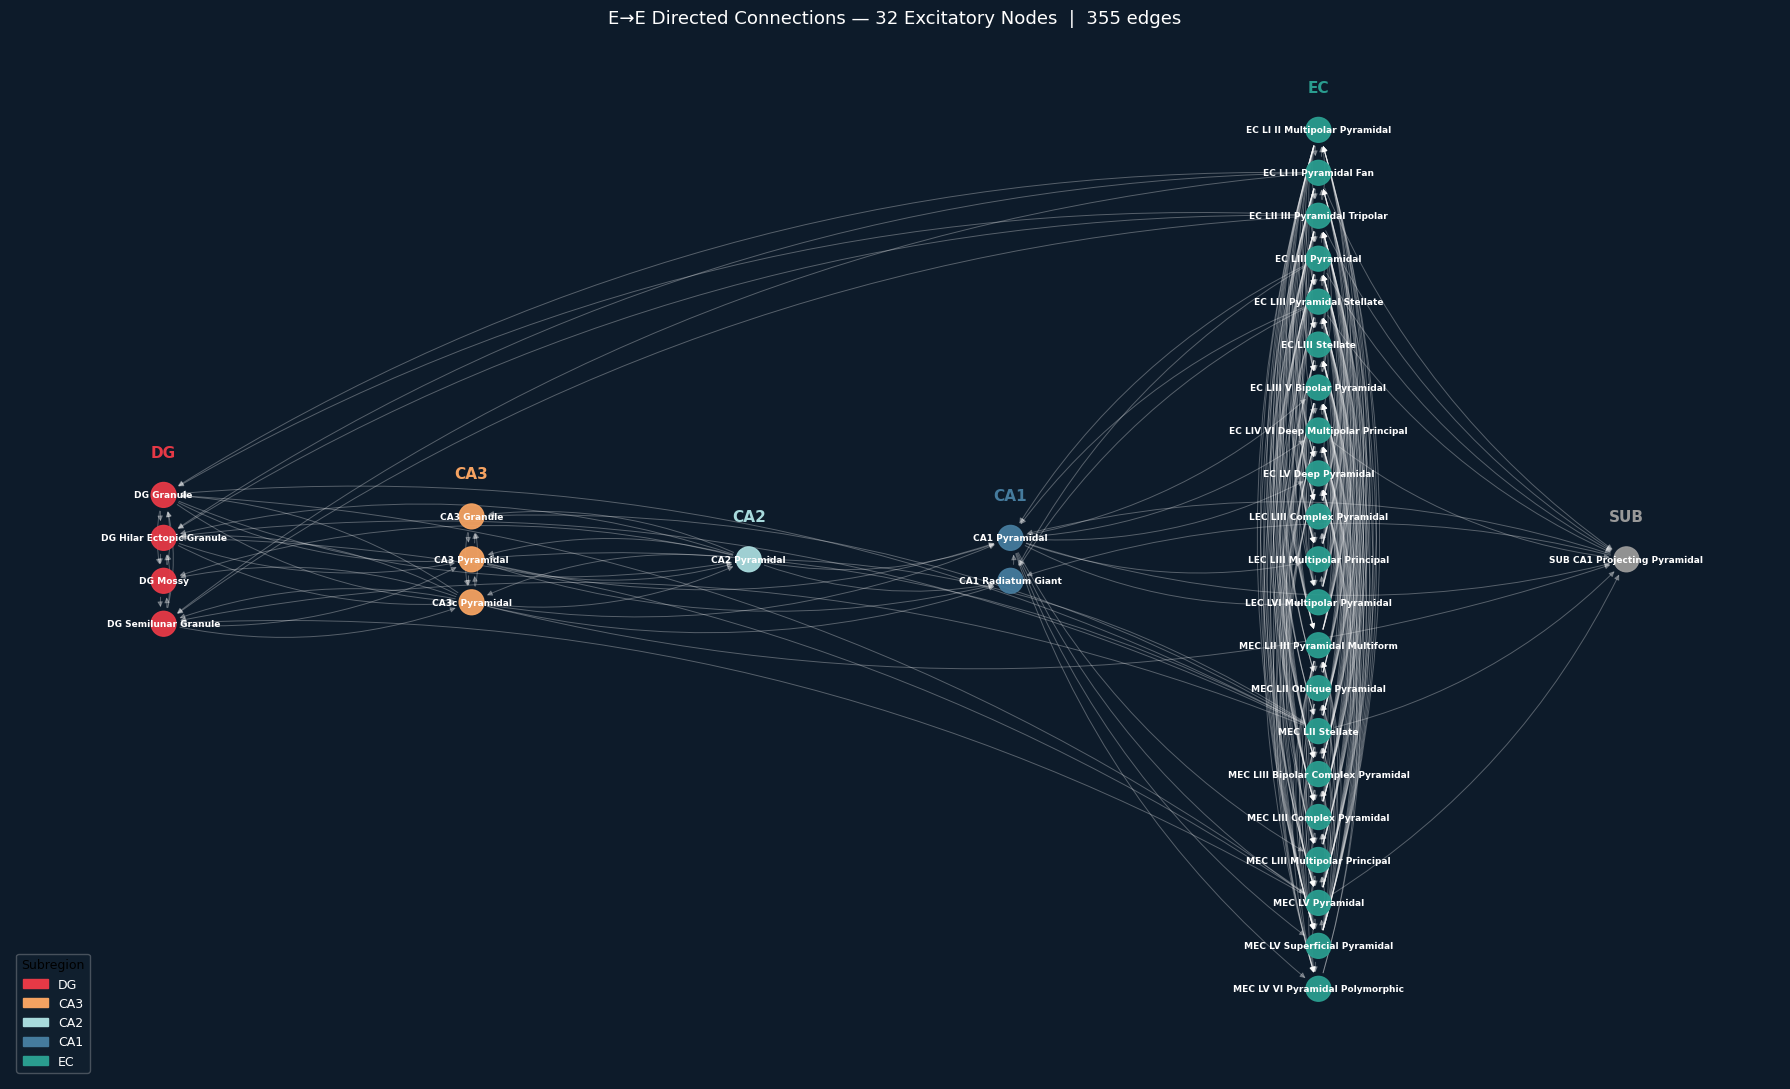

In [34]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Build E→E directed graph (existence only) ─────────────────────────────────
G = nx.DiGraph()
G.add_nodes_from(exc_nodes)
for src in exc_nodes:
    for tgt in exc_nodes:
        if W_EE_pos.loc[src, tgt] > 0:
            G.add_edge(src, tgt)

# ── Subregion assignment ───────────────────────────────────────────────────────
SUBREGION_PREFIXES = {
    "DG":  ("DG ",),
    "CA3": ("CA3",),
    "CA2": ("CA2",),
    "CA1": ("CA1",),
    "EC":  ("EC ", "MEC ", "LEC "),
    "SUB":  ("SUB",),
}

def get_subregion(node):
    for region, prefixes in SUBREGION_PREFIXES.items():
        if any(node.startswith(p) for p in prefixes):
            return region
    return "Other"

subregion_of = {n: get_subregion(n) for n in exc_nodes}

REGION_COLORS = {
    "DG":  "#E63946",
    "CA3": "#F4A261",
    "CA2": "#A8DADC",
    "CA1": "#457B9D",
    "EC":  "#2A9D8F",
    "SUB": "#999999",
}

REGION_CENTERS = {
    "DG":  (-3.0, 0.0),
    "CA3": (-1.0, 0.0),
    "CA2": ( 0.8, 0.0),
    "CA1": ( 2.5, 0.0),
    "EC":  ( 4.5, 0.0),
    "SUB":  (6.5, 0.0),
}

groups = {r: [] for r in REGION_CENTERS}
for n in exc_nodes:
    groups.setdefault(get_subregion(n), []).append(n)

pos = {}
for region, center in REGION_CENTERS.items():
    nodes_in_group = sorted(groups.get(region, []))
    n = len(nodes_in_group)
    y_start = (n - 1) * 0.55 / 2
    for i, node in enumerate(nodes_in_group):
        pos[node] = (center[0], y_start - i * 0.55)

node_colors = [REGION_COLORS[get_subregion(n)] for n in G.nodes()]

# ── Draw ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 11))
ax.set_facecolor("#0D1B2A")
fig.patch.set_facecolor("#0D1B2A")

nx.draw_networkx_edges(
    G, pos, ax=ax,
    width=0.7, edge_color="#FFFFFF", alpha=0.3,
    arrows=True, arrowsize=8,
    connectionstyle="arc3,rad=0.15",
    min_source_margin=12, min_target_margin=12,
)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors, node_size=320, alpha=0.95,
)
nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=6.5, font_color="white", font_weight="bold",
)

for region, center in REGION_CENTERS.items():
    nodes_in_group = groups.get(region, [])
    if not nodes_in_group:
        continue
    y_top = max(pos[n][1] for n in nodes_in_group) + 0.45
    ax.text(center[0], y_top, region, ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=REGION_COLORS[region])

legend_handles = [
    mpatches.Patch(color=REGION_COLORS[r], label=r)
    for r in ["DG", "CA3", "CA2", "CA1", "EC"]
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9,
          framealpha=0.3, facecolor="#1A2A3A", labelcolor="white",
          title="Subregion", title_fontsize=9)

ax.set_title(
    f"E→E Directed Connections — {len(exc_nodes)} Excitatory Nodes  |  "
    f"{G.number_of_edges()} edges",
    color="white", fontsize=13, pad=12,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage0_ee_directed_graph.png", dpi=300,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

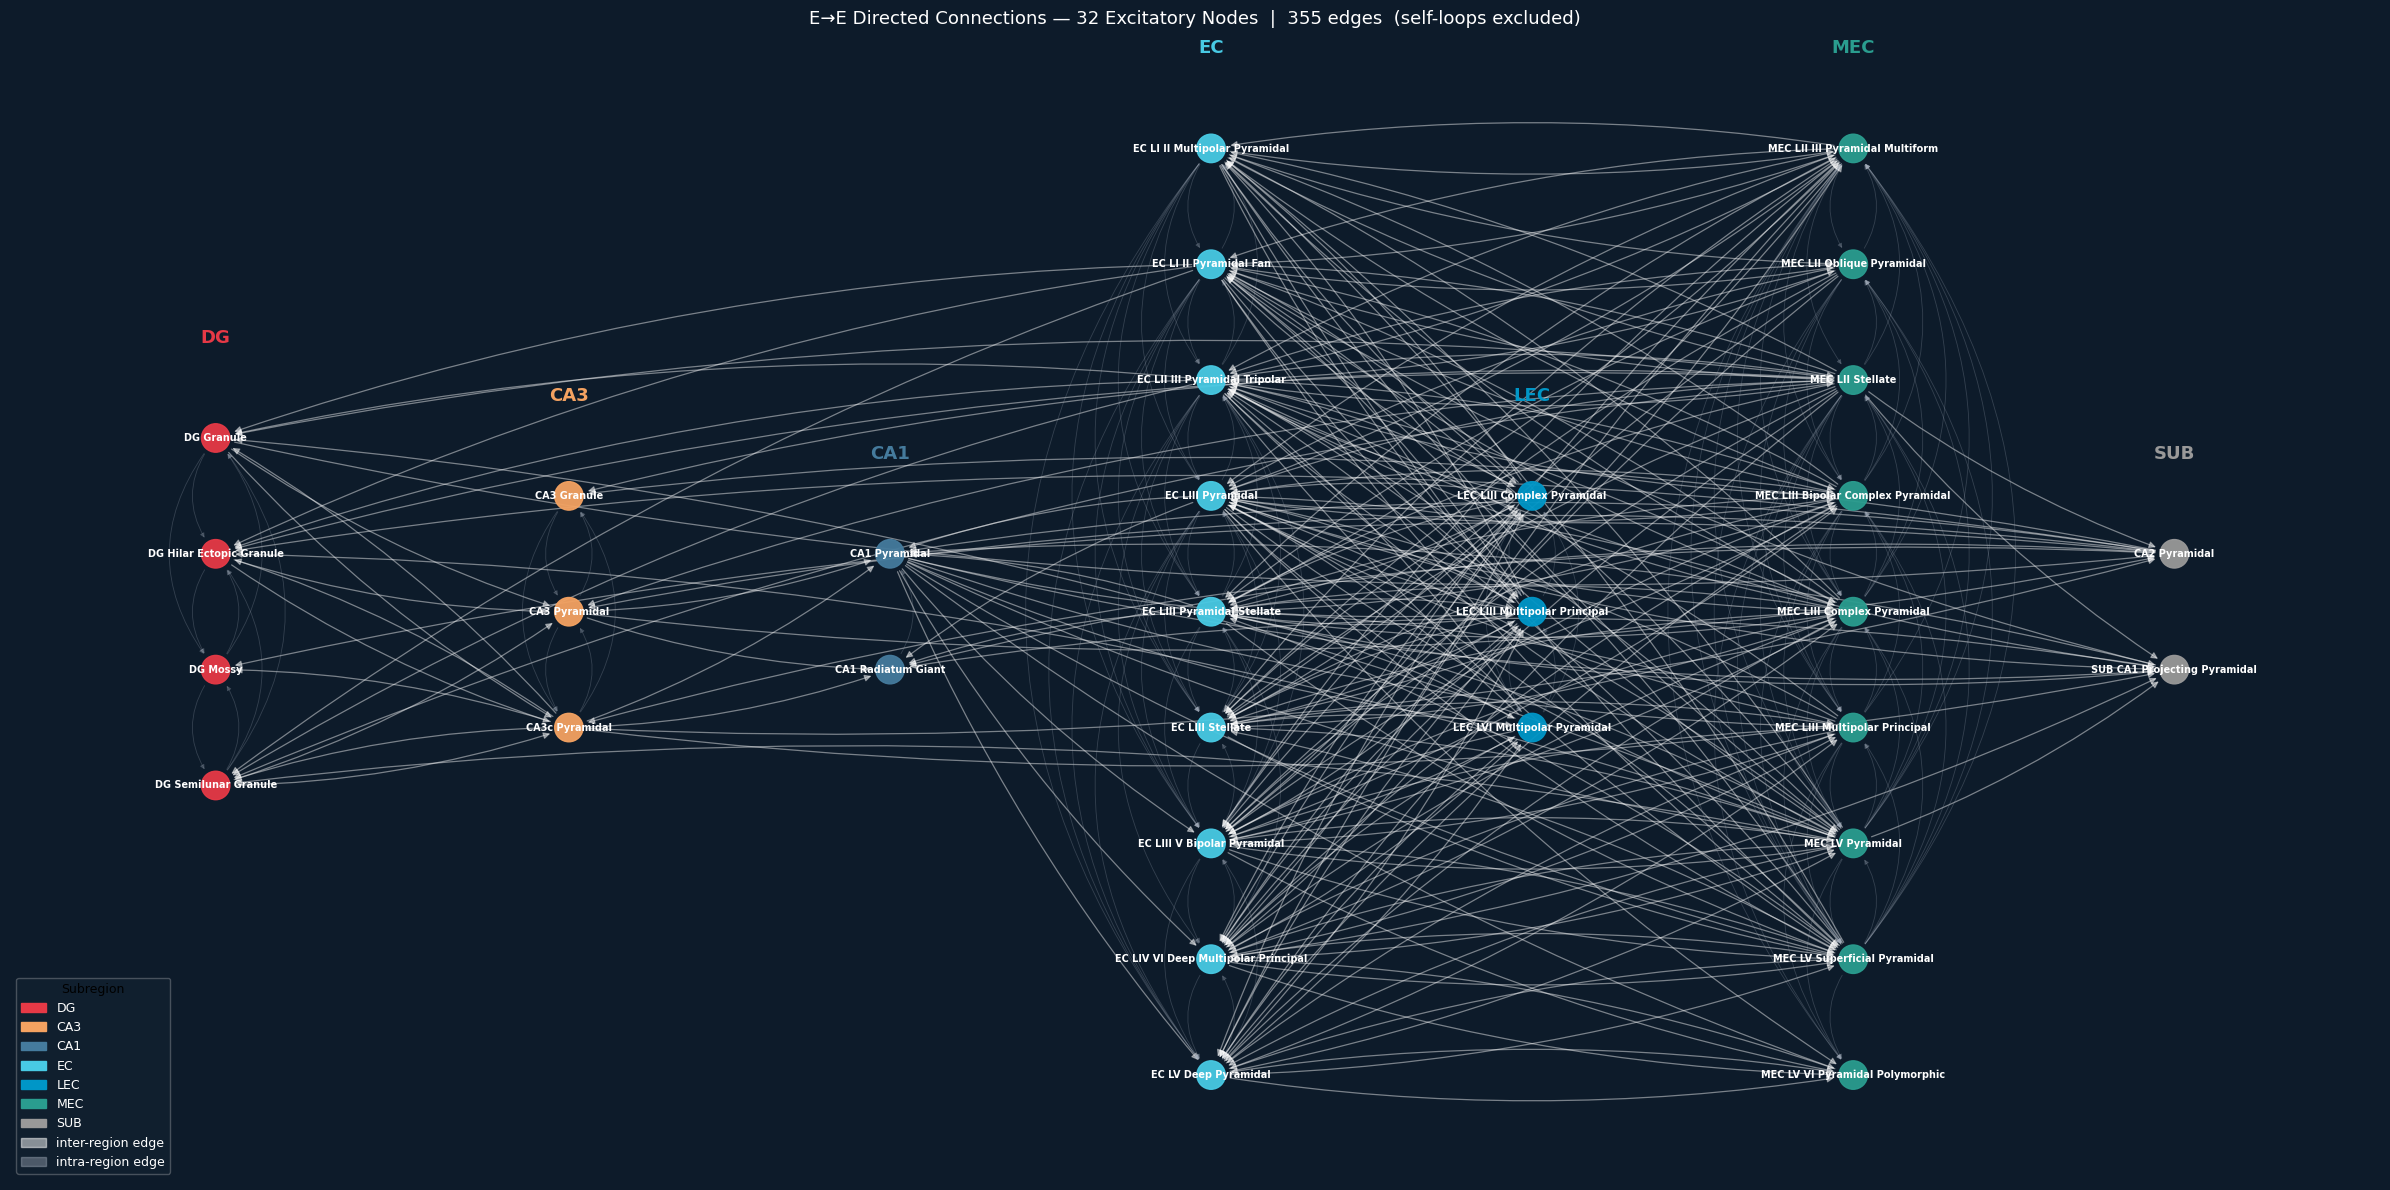

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

G = nx.DiGraph()
G.add_nodes_from(exc_nodes)
for src in exc_nodes:
    for tgt in exc_nodes:
        if src != tgt and W_EE_pos.loc[src, tgt] > 0:
            G.add_edge(src, tgt)

def get_subregion(node):
    if node.startswith("MEC "): return "MEC"
    if node.startswith("LEC "): return "LEC"
    if node.startswith("EC "):  return "EC"
    if node.startswith("CA3"):  return "CA3"
    if node.startswith("CA1"):  return "CA1"
    if node.startswith("DG "):  return "DG"
    return "Other"

REGION_COLORS = {
    "DG": "#E63946", "CA3": "#F4A261", "CA1": "#457B9D",
    "EC": "#48CAE4", "LEC": "#0096C7", "MEC": "#2A9D8F", "Other": "#999999",
}
REGION_X = {"DG": 0.0, "CA3": 2.2, "CA1": 4.2, "EC": 6.2, "LEC": 8.2, "MEC": 10.2}
V_SPACING = 0.70

groups = {r: [] for r in REGION_X}
for n in exc_nodes:
    groups[get_subregion(n)].append(n)

pos = {}
for region, x in REGION_X.items():
    nodes = sorted(groups.get(region, []))
    n = len(nodes)
    y_start = (n - 1) * V_SPACING / 2
    for i, node in enumerate(nodes):
        pos[node] = (x, y_start - i * V_SPACING)

intra_edges = [(u, v) for u, v in G.edges() if get_subregion(u) == get_subregion(v)]
inter_edges = [(u, v) for u, v in G.edges() if get_subregion(u) != get_subregion(v)]
node_colors = [REGION_COLORS[get_subregion(n)] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(24, 12))
ax.set_facecolor("#0D1B2A")
fig.patch.set_facecolor("#0D1B2A")

nx.draw_networkx_edges(G, pos, ax=ax, edgelist=inter_edges,
    width=0.9, edge_color="#FFFFFF", alpha=0.45, arrows=True, arrowsize=10,
    connectionstyle="arc3,rad=0.08", min_source_margin=14, min_target_margin=14)
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=intra_edges,
    width=0.6, edge_color="#A8B2C0", alpha=0.25, arrows=True, arrowsize=7,
    connectionstyle="arc3,rad=0.40", min_source_margin=14, min_target_margin=14)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=420, alpha=0.95)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.0, font_color="white", font_weight="bold")

for region, x in REGION_X.items():
    nodes = groups.get(region, [])
    if not nodes: continue
    y_top = max(pos[n][1] for n in nodes) + 0.55
    ax.text(x, y_top, region, ha="center", va="bottom",
            fontsize=13, fontweight="bold", color=REGION_COLORS[region])

legend_handles = [mpatches.Patch(color=REGION_COLORS[r], label=r)
                  for r in ["DG", "CA3", "CA1", "EC", "LEC", "MEC"]]
legend_handles += [
    mpatches.Patch(color="#FFFFFF", alpha=0.5, label="inter-region edge"),
    mpatches.Patch(color="#A8B2C0", alpha=0.4, label="intra-region edge"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9,
          framealpha=0.3, facecolor="#1A2A3A", labelcolor="white",
          title="Subregion", title_fontsize=9)
ax.set_title(
    f"E→E Directed Connections — {len(exc_nodes)} Excitatory Nodes  |  "
    f"{G.number_of_edges()} edges  (self-loops excluded)",
    color="white", fontsize=13, pad=14)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stage0_ee_directed_graph.png", dpi=300,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()